# Experiment: Wind Direction, 925 hPa Virtual Temperature, and 925 hPa Theta-e

Reuses setup from `scripts/causes-of-gph-extremas.ipynb` and adds reusable functions + hourly trajectory-point line graphs.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import metpy.calc as mpcalc
from metpy.units import units
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from pathlib import Path
from tqdm.auto import tqdm


/home/dmmsp/anaconda3/envs/water-transport-in-atmosphere/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Shared setup copied from causes-of-gph-extremas.ipynb, wrapped for reuse.
GPH_FILE = "era5_2021-nov_250-500-925_uv_pv_gph.nc"
TEMPERATURE_FILE = "era5_2021-nov_250-500-925_temperature.nc"
SPECIFIC_HUMIDITY_FILE = "specifichumidity_wind_1000-925hpa_2026-02-19.nc"

GPH_REGION_LON_MIN = 120.0
GPH_REGION_LON_MAX = 265.0
GPH_REGION_LAT_MIN = 30.0
GPH_REGION_LAT_MAX = 72.0
GPH_VMIN = 600.0
GPH_VMAX = 900.0

# These are used by _trace_gradient_path domain checks.
region_lon_min = GPH_REGION_LON_MIN
region_lon_max = GPH_REGION_LON_MAX
region_lat_min = 23.0
region_lat_max = GPH_REGION_LAT_MAX

gph_contour_levels = np.arange(560.0, 941.0, 20.0)


def resolve_data_path(filename: str) -> Path:
    candidates = [
        Path("../data") / filename,  # when kernel cwd is scripts/
        Path("data") / filename,     # when kernel cwd is repo root
    ]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        checked = ", ".join(str(p) for p in candidates)
        raise FileNotFoundError(f"Could not find {filename}. Checked: {checked}")
    return path


def open_dataset_from_data_dir(filename: str) -> xr.Dataset:
    return xr.open_dataset(resolve_data_path(filename))


def load_gph_925_context(gph_filename: str = GPH_FILE):
    gph_path = resolve_data_path(gph_filename)
    ds_local = xr.open_dataset(gph_path)

    if "z" not in ds_local.data_vars:
        raise RuntimeError("Expected variable 'z' in GPH dataset.")
    if "pressure_level" not in ds_local.coords:
        raise RuntimeError("Expected pressure_level coordinate in GPH dataset.")

    z_925_raw = ds_local["z"].sel(pressure_level=925)
    gph_925_m = xr.apply_ufunc(np.divide, z_925_raw, 9.80665)
    gph_925_m.name = "gph_925_m"

    return {
        "gph_dataset": ds_local,
        "gph_925_m_all": gph_925_m,
        "gph_path": gph_path,
    }


gph_context = load_gph_925_context()
ds = gph_context["gph_dataset"]
gph_source_dataset = ds
GPH_ERA5_PATH = str(gph_context["gph_path"])
gph_925_m_all = gph_context["gph_925_m_all"]

gph_925_m_all


<xarray.DataArray 'gph_925_m' (valid_time: 720, latitude: 721, longitude: 1440)> Size: 3GB
array([[[749.3739 , 749.3739 , 749.3739 , ..., 749.3739 , 749.3739 ,
         749.3739 ],
        [746.76086, 746.76086, 746.7481 , ..., 746.7864 , 746.7864 ,
         746.7736 ],
        [743.7782 , 743.76544, 743.74   , ..., 743.82916, 743.8037 ,
         743.79095],
        ...,
        [524.65393, 524.6667 , 524.6667 , ..., 524.6157 , 524.6284 ,
         524.6412 ],
        [522.2321 , 522.21936, 522.21936, ..., 522.2449 , 522.2321 ,
         522.2321 ],
        [521.0085 , 521.0085 , 521.0085 , ..., 521.0085 , 521.0085 ,
         521.0085 ]],

       [[747.99854, 747.99854, 747.99854, ..., 747.99854, 747.99854,
         747.99854],
        [745.42377, 745.42377, 745.411  , ..., 745.4492 , 745.4492 ,
         745.43646],
        [742.63226, 742.60675, 742.59406, ..., 742.6832 , 742.6578 ,
         742.645  ],
...
        [540.2865 , 540.27374, 540.2483 , ..., 540.3375 , 540.312  ,
         540.29926],
        [539.9424 , 539.9296 , 539.9169 , ..., 539.96783, 539.95514,
         539.9424 ],
        [539.5982 , 539.5982 , 539.5982 , ..., 539.5982 , 539.5982 ,
         539.5982 ]],

       [[675.16895, 675.16895, 675.16895, ..., 675.16895, 675.16895,
         675.16895],
        [672.50494, 672.5304 , 672.5559 , ..., 672.42847, 672.4539 ,
         672.47943],
        [669.535  , 669.586  , 669.6497 , ..., 669.3693 , 669.4203 ,
         669.484  ],
        ...,
        [541.43317, 541.40765, 541.3949 , ..., 541.4714 , 541.4586 ,
         541.4459 ],
        [540.79584, 540.79584, 540.7831 , ..., 540.83405, 540.82135,
         540.8086 ],
        [540.337  , 540.337  , 540.337  , ..., 540.337  , 540.337  ,
         540.337  ]]], shape=(720, 721, 1440), dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2021-11-01 ... 2021-11-30...
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    pressure_level  float64 8B 925.0
    expver          (valid_time) <U4 12kB ...
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [3]:
# Backward trajectory function copied from causes-of-gph-extremas.ipynb.
VANCOUVER_LAT = 49.28
VANCOUVER_LON = -123.12
VANCOUVER_LON_360 = VANCOUVER_LON % 360.0


def backward_integrate_trajectory_uv(
    ds,
    start_lat,
    start_lon,
    start_time,
    pressure_level=925,
    hours_back=72,
    substeps=4,
    earth_radius_m=6_371_000.0,
):
    """Backward trajectory using ERA5 u/v winds."""
    if substeps < 1:
        raise ValueError("substeps must be >= 1")

    ds_uv = ds[["u", "v"]].sel(pressure_level=pressure_level)
    t0 = pd.Timestamp(start_time).to_datetime64()
    t_nearest = ds_uv["valid_time"].sel(valid_time=t0, method="nearest").values

    window_start = np.datetime64(t_nearest) - np.timedelta64(hours_back + 2, "h")
    ds_uv = ds_uv.sel(valid_time=slice(window_start, np.datetime64(t_nearest))).load()

    times = pd.to_datetime(ds_uv["valid_time"].values)
    lat = float(start_lat)
    lon = float(start_lon) % 360.0

    records = [
        {
            "step_hour": 0,
            "valid_time": pd.Timestamp(t_nearest),
            "latitude": lat,
            "longitude": lon,
        }
    ]

    dt_hour_s = 3600.0
    dt_sub_s = dt_hour_s / substeps
    t_curr = np.datetime64(t_nearest)
    t_min = np.datetime64(times.min().to_datetime64())

    for h in tqdm(range(1, hours_back + 1), desc="Backward integration", unit="h"):
        if t_curr - np.timedelta64(1, "h") < t_min:
            break

        lat_step = lat
        lon_step = lon

        for s in range(substeps):
            sec_back = (s + 0.5) * dt_sub_s
            t_mid = t_curr - np.timedelta64(int(sec_back), "s")

            uv = ds_uv.interp(
                valid_time=t_mid,
                latitude=lat_step,
                longitude=lon_step,
                kwargs={"fill_value": "extrapolate"},
            )

            u_ms = float(uv["u"].values)
            v_ms = float(uv["v"].values)

            dlat_deg = np.degrees((v_ms * dt_sub_s) / earth_radius_m)
            coslat = max(np.cos(np.radians(lat_step)), 1e-6)
            dlon_deg = np.degrees((u_ms * dt_sub_s) / (earth_radius_m * coslat))

            lat_step = float(np.clip(lat_step - dlat_deg, -89.75, 89.75))
            lon_step = float((lon_step - dlon_deg) % 360.0)

        t_curr = t_curr - np.timedelta64(1, "h")
        lat = lat_step
        lon = lon_step

        records.append(
            {
                "step_hour": h,
                "valid_time": pd.Timestamp(t_curr),
                "latitude": lat,
                "longitude": lon,
            }
        )

    return pd.DataFrame(records)


trajectory_df = backward_integrate_trajectory_uv(
    ds,
    start_lat=VANCOUVER_LAT,
    start_lon=VANCOUVER_LON,
    start_time="2021-11-12T15:00:00",
    pressure_level=925,
    hours_back=72,
    substeps=4,
)

trajectory_df.head()


Backward integration: 100%|██████████| 72/72 [03:28<00:00,  2.89s/h]


,step_hour,valid_time,latitude,longitude
0,0,2021-11-12 15:00:00,49.280000,236.880000
1,1,2021-11-12 14:00:00,49.197853,236.595014
2,2,2021-11-12 13:00:00,49.099506,236.167762
3,3,2021-11-12 12:00:00,48.949713,235.744306
4,4,2021-11-12 11:00:00,48.809200,235.392474


In [4]:
# Gradient/extrema helper functions copied from causes-of-gph-extremas.ipynb.
GRAD_STEP_KM = 35.0
GRAD_PROBE_DEG = 0.20
GRAD_MIN_MAG_M_PER_KM = 0.02
GRAD_MAX_STEPS = 220
GRAD_MONOTONIC_TOL_M = 1e-3


def _interp_gph_value_local(gph2d, lon, lat):
    val = gph2d.interp(
        latitude=float(lat),
        longitude=float(lon),
        kwargs={"fill_value": "extrapolate"},
    )
    return float(val.values)


def _km_per_deg_lon(lat):
    return max(111.32 * np.cos(np.deg2rad(float(lat))), 1e-6)


def _local_gph_gradient_east_north(gph2d, lon, lat, probe_deg=0.20):
    lon = float(lon)
    lat = float(lat)
    h = float(probe_deg)

    g_lon_plus = _interp_gph_value_local(gph2d, lon + h, lat)
    g_lon_minus = _interp_gph_value_local(gph2d, lon - h, lat)
    g_lat_plus = _interp_gph_value_local(gph2d, lon, lat + h)
    g_lat_minus = _interp_gph_value_local(gph2d, lon, lat - h)

    dgd_lon_deg = (g_lon_plus - g_lon_minus) / (2.0 * h)
    dgd_lat_deg = (g_lat_plus - g_lat_minus) / (2.0 * h)

    dgd_east = dgd_lon_deg / _km_per_deg_lon(lat)
    dgd_north = dgd_lat_deg / 111.32

    return np.array([float(dgd_east), float(dgd_north)], dtype=float)


def _trace_gradient_path(
    gph2d,
    lon0,
    lat0,
    prefer="increase",
    step_km=35.0,
    probe_deg=0.20,
    grad_min_mag=0.02,
    max_steps=220,
    monotonic_tol=1e-3,
):
    lon0 = float(lon0)
    lat0 = float(lat0)

    base_val = _interp_gph_value_local(gph2d, lon0, lat0)
    samples = [(lon0, lat0, base_val)]
    stop_reason = "max_steps"

    for _ in range(max_steps):
        curr_lon, curr_lat, curr_val = samples[-1]

        grad = _local_gph_gradient_east_north(
            gph2d,
            curr_lon,
            curr_lat,
            probe_deg=probe_deg,
        )
        grad_mag = float(np.linalg.norm(grad))

        if not np.isfinite(grad_mag) or grad_mag < float(grad_min_mag):
            stop_reason = "gradient_too_small"
            break

        step_dir = grad / grad_mag
        if prefer == "decrease":
            step_dir = -step_dir

        d_east_km = float(step_dir[0]) * float(step_km)
        d_north_km = float(step_dir[1]) * float(step_km)

        next_lon = curr_lon + d_east_km / _km_per_deg_lon(curr_lat)
        next_lat = curr_lat + d_north_km / 111.32

        if (
            next_lon < region_lon_min
            or next_lon > region_lon_max
            or next_lat < region_lat_min
            or next_lat > region_lat_max
        ):
            stop_reason = "domain_edge"
            break

        next_val = _interp_gph_value_local(gph2d, next_lon, next_lat)
        if not np.isfinite(next_val):
            stop_reason = "nan"
            break

        if prefer == "decrease":
            if not (next_val < curr_val - monotonic_tol):
                stop_reason = "cannot_decrease"
                break
        else:
            if not (next_val > curr_val + monotonic_tol):
                stop_reason = "cannot_increase"
                break

        samples.append((float(next_lon), float(next_lat), float(next_val)))

    line = np.asarray([(p[0], p[1]) for p in samples], dtype=float)
    final_lon, final_lat, final_val = samples[-1]

    return {
        "line": line,
        "final_lon": float(final_lon),
        "final_lat": float(final_lat),
        "final_value": float(final_val),
        "stop_reason": stop_reason,
        "num_steps": int(len(samples) - 1),
    }


def _nearest_contour_segment_to_point(gph2d, levels, lon_ref, lat_ref):
    levels = np.asarray(levels, dtype=float)
    levels = np.unique(np.sort(levels[np.isfinite(levels)]))
    if levels.size == 0:
        return None

    fig, ax = plt.subplots(figsize=(3, 2))
    cs = ax.contour(
        gph2d["longitude"].values,
        gph2d["latitude"].values,
        gph2d.values,
        levels=levels,
    )
    plt.close(fig)

    lon_ref = float(lon_ref)
    lat_ref = float(lat_ref)
    lon_scale = max(np.cos(np.deg2rad(lat_ref)), 1e-6)

    best = None

    for level, segs in zip(cs.levels, cs.allsegs):
        for seg in segs:
            seg = np.asarray(seg, dtype=float)
            if seg.shape[0] < 2:
                continue

            d = np.sqrt(((seg[:, 0] - lon_ref) * lon_scale) ** 2 + (seg[:, 1] - lat_ref) ** 2)
            idx = int(np.argmin(d))
            dist = float(d[idx])

            if best is None or dist < best["distance"]:
                best = {
                    "level": float(level),
                    "segment": seg,
                    "nearest_point": seg[idx],
                    "distance": dist,
                }

    return best


In [5]:
# Reusable precompute: GPH extrema for each hourly trajectory point.
FRAME_STEP_HOURS = 6


def _lat_slice_from_bounds(lat_coord, lat_min, lat_max):
    lat_values = np.asarray(lat_coord.values, dtype=float)
    if lat_values[0] > lat_values[-1]:
        return slice(float(lat_max), float(lat_min))
    return slice(float(lat_min), float(lat_max))


def _build_trajectory_frame_rows(trajectory_df, frame_step_hours=6):
    traj = trajectory_df.copy()
    traj["valid_time"] = pd.to_datetime(traj["valid_time"])
    traj["longitude_360"] = traj["longitude"] % 360.0

    if "step_hour" in traj.columns:
        frame_rows = (
            traj.loc[traj["step_hour"] % frame_step_hours == 0]
            .sort_values("step_hour", ascending=False)
            .reset_index(drop=True)
        )
        trajectory_line = traj.sort_values("step_hour", ascending=False).copy()
    else:
        trajectory_line = traj.sort_values("valid_time", ascending=True).copy()
        frame_rows = trajectory_line.iloc[::frame_step_hours].copy().reset_index(drop=True)
        frame_rows["step_hour"] = np.nan

    if frame_rows.empty:
        raise RuntimeError(f"No {frame_step_hours}-hour trajectory points found.")

    frame_times = pd.to_datetime(frame_rows["valid_time"]).dt.round("h")
    frame_times_da = xr.DataArray(frame_times.to_numpy(dtype="datetime64[ns]"), dims="frame")

    return {
        "trajectory_df": traj,
        "trajectory_line": trajectory_line,
        "frame_rows": frame_rows,
        "frame_times": frame_times,
        "frame_times_da": frame_times_da,
    }


def compute_gph_extrema_for_hourly_points(
    trajectory_df,
    gph_925_m_all,
    frame_step_hours=6,
    extent_lon_min=None,
    extent_lon_max=None,
    extent_lat_min=23.0,
    extent_lat_max=None,
    extrema_search_levels=None,
):
    extent_lon_min = float(GPH_REGION_LON_MIN if extent_lon_min is None else extent_lon_min)
    extent_lon_max = float(GPH_REGION_LON_MAX if extent_lon_max is None else extent_lon_max)
    extent_lat_max = float(GPH_REGION_LAT_MAX if extent_lat_max is None else extent_lat_max)
    extent_lat_min = float(extent_lat_min)

    global region_lon_min, region_lon_max, region_lat_min, region_lat_max
    region_lon_min = extent_lon_min
    region_lon_max = extent_lon_max
    region_lat_min = extent_lat_min
    region_lat_max = extent_lat_max

    traj_context = _build_trajectory_frame_rows(trajectory_df, frame_step_hours=frame_step_hours)
    frame_rows = traj_context["frame_rows"]
    frame_times_da = traj_context["frame_times_da"]

    lat_slice = _lat_slice_from_bounds(gph_925_m_all["latitude"], extent_lat_min, extent_lat_max)
    gph_region = gph_925_m_all.sel(
        longitude=slice(extent_lon_min, extent_lon_max),
        latitude=lat_slice,
    )
    gph_frames = gph_region.sel(valid_time=frame_times_da, method="nearest").load()

    if extrema_search_levels is None:
        extrema_search_levels = np.asarray(
            globals().get("gph_contour_levels", np.arange(560.0, 941.0, 20.0)),
            dtype=float,
        )
    extrema_search_levels = np.unique(np.sort(extrema_search_levels[np.isfinite(extrema_search_levels)]))

    records = []
    summary_rows = []

    for i, row in tqdm(frame_rows.iterrows(), total=len(frame_rows), desc="Tracing extrema", unit="frame"):
        frame_ts = pd.Timestamp(row["valid_time"]).round("h")
        frame_step = row.get("step_hour", np.nan)
        gph_frame = gph_frames.isel(frame=i)

        lon_curr = float(row["longitude_360"])
        lat_curr = float(row["latitude"])

        dec_trace = _trace_gradient_path(
            gph_frame,
            lon_curr,
            lat_curr,
            prefer="decrease",
            step_km=GRAD_STEP_KM,
            probe_deg=GRAD_PROBE_DEG,
            grad_min_mag=GRAD_MIN_MAG_M_PER_KM,
            max_steps=GRAD_MAX_STEPS,
            monotonic_tol=GRAD_MONOTONIC_TOL_M,
        )
        inc_trace = _trace_gradient_path(
            gph_frame,
            lon_curr,
            lat_curr,
            prefer="increase",
            step_km=GRAD_STEP_KM,
            probe_deg=GRAD_PROBE_DEG,
            grad_min_mag=GRAD_MIN_MAG_M_PER_KM,
            max_steps=GRAD_MAX_STEPS,
            monotonic_tol=GRAD_MONOTONIC_TOL_M,
        )

        dec_closest = _nearest_contour_segment_to_point(
            gph_frame,
            extrema_search_levels,
            dec_trace["final_lon"],
            dec_trace["final_lat"],
        )
        inc_closest = _nearest_contour_segment_to_point(
            gph_frame,
            extrema_search_levels,
            inc_trace["final_lon"],
            inc_trace["final_lat"],
        )

        long_end_a = np.array([dec_trace["final_lon"], dec_trace["final_lat"]], dtype=float)
        long_end_b = np.array([inc_trace["final_lon"], inc_trace["final_lat"]], dtype=float)

        extrema_levels = []
        if dec_closest is not None:
            extrema_levels.append(float(dec_closest["level"]))
        if inc_closest is not None:
            extrema_levels.append(float(inc_closest["level"]))
        extrema_levels = np.unique(np.asarray(extrema_levels, dtype=float))

        record = {
            "frame_index": int(i),
            "frame_time": frame_ts,
            "step_hour": frame_step,
            "lon_curr": lon_curr,
            "lat_curr": lat_curr,
            "gph_frame": gph_frame,
            "dec_trace": dec_trace,
            "inc_trace": inc_trace,
            "dec_closest": dec_closest,
            "inc_closest": inc_closest,
            "long_end_a": long_end_a,
            "long_end_b": long_end_b,
            "extrema_levels": extrema_levels,
        }
        records.append(record)

        summary_rows.append(
            {
                "frame_index": int(i),
                "valid_time": frame_ts,
                "step_hour": frame_step,
                "curr_lon": lon_curr,
                "curr_lat": lat_curr,
                "dec_level_m": float(dec_closest["level"]) if dec_closest is not None else np.nan,
                "inc_level_m": float(inc_closest["level"]) if inc_closest is not None else np.nan,
                "dec_stop_reason": dec_trace["stop_reason"],
                "inc_stop_reason": inc_trace["stop_reason"],
            }
        )

    return {
        **traj_context,
        "gph_frames": gph_frames,
        "records": records,
        "extrema_df": pd.DataFrame(summary_rows),
        "extrema_search_levels": extrema_search_levels,
        "lat_slice": lat_slice,
        "extent_lon_min": extent_lon_min,
        "extent_lon_max": extent_lon_max,
        "extent_lat_min": extent_lat_min,
        "extent_lat_max": extent_lat_max,
        "frame_step_hours": frame_step_hours,
    }


extrema_context = compute_gph_extrema_for_hourly_points(
    trajectory_df=trajectory_df,
    gph_925_m_all=gph_925_m_all,
    frame_step_hours=FRAME_STEP_HOURS,
)

extrema_context["extrema_df"].head()


Tracing extrema: 100%|██████████| 13/13 [00:14<00:00,  1.10s/frame]


,frame_index,valid_time,step_hour,curr_lon,curr_lat,dec_level_m,inc_level_m,dec_stop_reason,inc_stop_reason
0,0,2021-11-09 15:00:00,72,185.390960,40.701622,560.0,840.0,gradient_too_small,gradient_too_small
1,1,2021-11-09 21:00:00,66,188.772725,40.308731,560.0,840.0,cannot_decrease,gradient_too_small
2,2,2021-11-10 03:00:00,60,192.442406,39.891847,600.0,820.0,gradient_too_small,gradient_too_small
3,3,2021-11-10 09:00:00,54,196.369952,39.225400,620.0,820.0,gradient_too_small,gradient_too_small
4,4,2021-11-10 15:00:00,48,200.231815,39.100452,600.0,820.0,gradient_too_small,gradient_too_small


In [6]:
# Precompute 925 hPa thermodynamic backgrounds at the same frame times.

def _time_coord_name(ds):
    if "valid_time" in ds.coords:
        return "valid_time"
    if "time" in ds.coords:
        return "time"
    raise RuntimeError("Expected a valid_time/time coordinate in dataset.")


def compute_925hpa_virtual_temperature_and_thetae(extrema_context, pressure_level_hpa=925.0):
    temp_ds = open_dataset_from_data_dir(TEMPERATURE_FILE)
    humid_ds = open_dataset_from_data_dir(SPECIFIC_HUMIDITY_FILE)

    temp_time_coord = _time_coord_name(temp_ds)
    humid_time_coord = _time_coord_name(humid_ds)

    if "t" not in temp_ds.data_vars:
        raise RuntimeError("Expected variable 't' in temperature dataset.")
    if "q" not in humid_ds.data_vars:
        raise RuntimeError("Expected variable 'q' in specific humidity dataset.")
    if "pressure_level" not in temp_ds.coords or "pressure_level" not in humid_ds.coords:
        raise RuntimeError("Expected pressure_level coordinate in both temperature and humidity datasets.")

    frame_times_da = extrema_context["frame_times_da"]
    lat_slice = extrema_context["lat_slice"]
    extent_lon_min = float(extrema_context["extent_lon_min"])
    extent_lon_max = float(extrema_context["extent_lon_max"])

    t_region = temp_ds["t"].sel(
        pressure_level=pressure_level_hpa,
        longitude=slice(extent_lon_min, extent_lon_max),
        latitude=lat_slice,
    )
    q_region = humid_ds["q"].sel(
        pressure_level=pressure_level_hpa,
        longitude=slice(extent_lon_min, extent_lon_max),
        latitude=lat_slice,
    )

    t_frames = t_region.sel({temp_time_coord: frame_times_da}, method="nearest").load()
    q_frames = q_region.sel({humid_time_coord: frame_times_da}, method="nearest").load()
    q_frames = xr.apply_ufunc(np.clip, q_frames, 1e-8, 0.5)

    mixing_ratio = mpcalc.mixing_ratio_from_specific_humidity(
        q_frames.values * units.dimensionless
    )
    virtual_temp = mpcalc.virtual_temperature(
        t_frames.values * units.kelvin,
        mixing_ratio,
    ).magnitude

    dewpoint = mpcalc.dewpoint_from_specific_humidity(
        pressure_level_hpa * units.hPa,
        t_frames.values * units.kelvin,
        q_frames.values * units.dimensionless,
    )
    theta_e = mpcalc.equivalent_potential_temperature(
        pressure_level_hpa * units.hPa,
        t_frames.values * units.kelvin,
        dewpoint,
    ).magnitude

    virtual_temp_frames = xr.DataArray(
        virtual_temp,
        coords=t_frames.coords,
        dims=t_frames.dims,
        name=f"virtual_temperature_{int(np.round(pressure_level_hpa))}hpa",
        attrs={"units": "K"},
    )
    theta_e_frames = xr.DataArray(
        theta_e,
        coords=t_frames.coords,
        dims=t_frames.dims,
        name=f"theta_e_{int(np.round(pressure_level_hpa))}hpa",
        attrs={"units": "K"},
    )

    temp_ds.close()
    humid_ds.close()

    return {
        "virtual_temp_frames": virtual_temp_frames,
        "theta_e_frames": theta_e_frames,
        "pressure_level_hpa": float(pressure_level_hpa),
    }


thermo_context = compute_925hpa_virtual_temperature_and_thetae(
    extrema_context,
    pressure_level_hpa=925.0,
)
virtual_temp_frames = thermo_context["virtual_temp_frames"]
theta_e_frames = thermo_context["theta_e_frames"]

virtual_temp_frames


<xarray.DataArray 'virtual_temperature_925hpa' (frame: 13, latitude: 197,
                                                longitude: 581)> Size: 6MB
array([[[259.31326, 259.34003, 259.3817 , ..., 263.08246, 263.02917,
         262.97324],
        [259.3643 , 259.39105, 259.42368, ..., 262.81744, 262.68143,
         262.53366],
        [259.3576 , 259.35587, 259.3639 , ..., 262.8615 , 262.63715,
         262.3778 ],
        ...,
        [289.2083 , 290.16708, 290.20398, ..., 290.84277, 290.5872 ,
         290.36807],
        [289.8235 , 290.7505 , 290.9543 , ..., 291.03394, 290.82837,
         290.6171 ],
        [290.26987, 290.89124, 291.0037 , ..., 291.26846, 291.05743,
         290.88547]],

       [[258.78128, 258.78442, 258.79272, ..., 262.69296, 262.47357,
         262.34366],
        [258.74286, 258.7382 , 258.74722, ..., 261.90125, 261.59155,
         261.34833],
        [258.74506, 258.75623, 258.77692, ..., 261.41135, 261.0362 ,
         260.71576],
...
        [291.941  , 292.53873, 292.57462, ..., 293.13065, 293.07394,
         293.0062 ],
        [291.83286, 292.25168, 292.81158, ..., 293.08762, 293.05292,
         293.04413],
        [291.78165, 292.1455 , 292.92505, ..., 293.17407, 293.1156 ,
         293.0362 ]],

       [[259.34793, 259.35657, 259.38467, ..., 264.21335, 264.04095,
         263.88943],
        [259.26587, 259.28827, 259.32034, ..., 264.34644, 264.18912,
         264.069  ],
        [259.18475, 259.18988, 259.20276, ..., 265.02142, 264.90912,
         264.79642],
        ...,
        [291.89478, 292.19064, 292.59412, ..., 292.82407, 292.9635 ,
         292.7957 ],
        [292.10538, 292.19754, 292.63297, ..., 292.85037, 292.8937 ,
         292.77493],
        [292.00098, 291.9931 , 292.79288, ..., 292.89587, 292.83002,
         292.74072]]], shape=(13, 197, 581), dtype=float32)
Coordinates:
  * latitude        (latitude) float64 2kB 72.0 71.75 71.5 ... 23.5 23.25 23.0
  * longitude       (longitude) float64 5kB 120.0 120.2 120.5 ... 264.8 265.0
    number          int64 8B 0
    valid_time      (frame) datetime64[ns] 104B 2021-11-09T15:00:00 ... 2021-...
    pressure_level  float64 8B 925.0
    expver          (frame) <U4 208B '0001' '0001' '0001' ... '0001' '0001'
Dimensions without coordinates: frame
Attributes:
    units:    K

## Hourly trajectory-point thermodynamic line graphs


In [ ]:
# Compute 925 hPa virtual temperature and theta-e at each hourly trajectory point.

def compute_trajectory_hourly_thermo_series(trajectory_df, pressure_level_hpa=925.0):
    temp_ds = open_dataset_from_data_dir(TEMPERATURE_FILE)
    humid_ds = open_dataset_from_data_dir(SPECIFIC_HUMIDITY_FILE)

    temp_time_coord = _time_coord_name(temp_ds)
    humid_time_coord = _time_coord_name(humid_ds)

    traj = trajectory_df.copy()
    traj["valid_time"] = pd.to_datetime(traj["valid_time"])
    traj["longitude_360"] = traj["longitude"] % 360.0

    point_times = xr.DataArray(traj["valid_time"].to_numpy(dtype="datetime64[ns]"), dims="point")
    point_lats = xr.DataArray(traj["latitude"].to_numpy(dtype=float), dims="point")
    point_lons = xr.DataArray(traj["longitude_360"].to_numpy(dtype=float), dims="point")

    t_925 = temp_ds["t"].sel(pressure_level=pressure_level_hpa)
    q_925 = humid_ds["q"].sel(pressure_level=pressure_level_hpa)

    t_points = t_925.interp(
        {
            temp_time_coord: point_times,
            "latitude": point_lats,
            "longitude": point_lons,
        },
        kwargs={"fill_value": "extrapolate"},
    ).load()

    q_points = q_925.interp(
        {
            humid_time_coord: point_times,
            "latitude": point_lats,
            "longitude": point_lons,
        },
        kwargs={"fill_value": "extrapolate"},
    ).load()

    q_points = xr.apply_ufunc(np.clip, q_points, 1e-8, 0.5)

    mixing_ratio = mpcalc.mixing_ratio_from_specific_humidity(
        q_points.values * units.dimensionless
    )
    virtual_temp = mpcalc.virtual_temperature(
        t_points.values * units.kelvin,
        mixing_ratio,
    ).magnitude

    dewpoint = mpcalc.dewpoint_from_specific_humidity(
        pressure_level_hpa * units.hPa,
        t_points.values * units.kelvin,
        q_points.values * units.dimensionless,
    )
    theta_e = mpcalc.equivalent_potential_temperature(
        pressure_level_hpa * units.hPa,
        t_points.values * units.kelvin,
        dewpoint,
    ).magnitude

    temp_ds.close()
    humid_ds.close()

    out = traj[["step_hour", "valid_time", "latitude", "longitude", "longitude_360"]].copy()
    out["virtual_temperature_K"] = np.asarray(virtual_temp, dtype=float)
    out["theta_e_K"] = np.asarray(theta_e, dtype=float)
    out = out.sort_values("step_hour", ascending=True).reset_index(drop=True)
    return out


trajectory_thermo_df = compute_trajectory_hourly_thermo_series(
    trajectory_df,
    pressure_level_hpa=925.0,
)

trajectory_thermo_df.head()


In [ ]:
# Line graph: 925 hPa virtual temperature at each hourly trajectory point.
plot_df = trajectory_thermo_df.sort_values("step_hour", ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    plot_df["step_hour"],
    plot_df["virtual_temperature_K"],
    color="tab:blue",
    linewidth=2.0,
    marker="o",
    markersize=3.5,
)
ax.set_xlabel("Backward trajectory step hour")
ax.set_ylabel("Virtual temperature (K)")
ax.set_title("925 hPa virtual temperature along hourly backward trajectory")
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(float(plot_df["step_hour"].max()), float(plot_df["step_hour"].min()))
plt.tight_layout()
plt.show()


In [ ]:
# Line graph: 925 hPa theta-e at each hourly trajectory point.
plot_df = trajectory_thermo_df.sort_values("step_hour", ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    plot_df["step_hour"],
    plot_df["theta_e_K"],
    color="tab:orange",
    linewidth=2.0,
    marker="o",
    markersize=3.5,
)
ax.set_xlabel("Backward trajectory step hour")
ax.set_ylabel("Theta-e (K)")
ax.set_title("925 hPa equivalent potential temperature (theta-e) along hourly backward trajectory")
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(float(plot_df["step_hour"].max()), float(plot_df["step_hour"].min()))
plt.tight_layout()
plt.show()


In [7]:
# Plot helper that keeps the same trajectory/extrema structure as the old cell,
# while swapping the background field.

def _build_discrete_colormap(field_frames, bin_width, cmap_name):
    bin_width = float(bin_width)
    vmin = float(np.floor(float(field_frames.min().values) / bin_width) * bin_width)
    vmax = float(np.ceil(float(field_frames.max().values) / bin_width) * bin_width)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise RuntimeError("Non-finite background range encountered.")
    if vmax <= vmin:
        vmax = vmin + bin_width

    levels = np.arange(vmin, vmax + bin_width, bin_width)
    nbins = max(len(levels) - 1, 1)
    cmap = plt.get_cmap(cmap_name, nbins)
    norm = mcolors.BoundaryNorm(levels, ncolors=nbins, clip=True)

    return levels, cmap, norm


def plot_background_with_extrema(
    extrema_context,
    background_frames,
    field_name,
    colorbar_label,
    cmap_name="Spectral_r",
    bin_width=1.0,
):
    frame_rows = extrema_context["frame_rows"]
    trajectory_line = extrema_context["trajectory_line"]
    gph_frames = extrema_context["gph_frames"]
    records = extrema_context["records"]

    if "frame" not in background_frames.dims:
        raise RuntimeError("background_frames must have a 'frame' dimension.")
    if background_frames.sizes["frame"] != len(records):
        raise RuntimeError("background_frames frame count must match extrema records.")

    line_lons = trajectory_line["longitude_360"].to_numpy(dtype=float)
    line_lats = trajectory_line["latitude"].to_numpy(dtype=float)

    extent_lon_min = float(extrema_context["extent_lon_min"])
    extent_lon_max = float(extrema_context["extent_lon_max"])
    extent_lat_min = float(extrema_context["extent_lat_min"])
    extent_lat_max = float(extrema_context["extent_lat_max"])

    levels, cmap, norm = _build_discrete_colormap(background_frames, bin_width, cmap_name)

    for i, row in frame_rows.iterrows():
        record = records[i]
        frame_ts = pd.Timestamp(row["valid_time"]).round("h")
        frame_step = row.get("step_hour", np.nan)

        background_frame = background_frames.isel(frame=i)
        gph_frame = gph_frames.isel(frame=i)

        lon_curr = float(row["longitude_360"])
        lat_curr = float(row["latitude"])

        long_end_a = np.asarray(record["long_end_a"], dtype=float)
        long_end_b = np.asarray(record["long_end_b"], dtype=float)
        extrema_levels = np.asarray(record["extrema_levels"], dtype=float)

        fig = plt.figure(figsize=(14, 7))
        ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
        ax.set_extent([extent_lon_min, extent_lon_max, extent_lat_min, extent_lat_max], crs=ccrs.PlateCarree())

        ax.coastlines(resolution="110m", linewidth=0.8, color="black")
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="black")

        mesh = ax.pcolormesh(
            background_frame["longitude"],
            background_frame["latitude"],
            background_frame,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading="auto",
            zorder=1,
        )

        contour_handle_for_legend = None
        if extrema_levels.size > 0:
            ax.contour(
                gph_frame["longitude"],
                gph_frame["latitude"],
                gph_frame,
                levels=extrema_levels,
                colors="black",
                linewidths=1.7,
                alpha=0.95,
                transform=ccrs.PlateCarree(),
                zorder=7,
            )
            contour_handle_for_legend = Line2D([0], [0], color="black", lw=1.7)

        (between_extrema_handle,) = ax.plot(
            [float(long_end_a[0]) % 360.0, float(long_end_b[0]) % 360.0],
            [float(long_end_a[1]), float(long_end_b[1])],
            color="magenta",
            linewidth=2.0,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=9,
            label="Line between extrema stops",
        )

        extrema_endpoints_handle = ax.scatter(
            [float(long_end_a[0]) % 360.0, float(long_end_b[0]) % 360.0],
            [float(long_end_a[1]), float(long_end_b[1])],
            s=42,
            c="magenta",
            marker="x",
            linewidths=1.3,
            transform=ccrs.PlateCarree(),
            zorder=10,
            label="Extrema stops",
        )

        (traj_line_handle,) = ax.plot(
            line_lons,
            line_lats,
            color="white",
            linewidth=1.8,
            alpha=0.95,
            transform=ccrs.PlateCarree(),
            zorder=6,
            label="Backward trajectory (72h to 0h)",
        )

        traj_points_handle = ax.scatter(
            line_lons,
            line_lats,
            s=18,
            c="black",
            alpha=0.35,
            transform=ccrs.PlateCarree(),
            zorder=6,
            label="Trajectory hourly points",
        )

        current_handle = ax.scatter(
            [lon_curr],
            [lat_curr],
            marker="x",
            s=130,
            c="deepskyblue",
            linewidths=2.3,
            transform=ccrs.PlateCarree(),
            zorder=10,
            label=f"Current {extrema_context['frame_step_hours']}h point",
        )

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

        step_text = (
            f"t-{int(frame_step)}h"
            if pd.notna(frame_step)
            else f"{extrema_context['frame_step_hours']}h sample"
        )
        ax.set_title(
            f"{field_name} + extrema contours | {frame_ts.strftime('%Y-%m-%d %H:%M UTC')} ({step_text})"
        )

        cbar = plt.colorbar(
            mesh,
            ax=ax,
            boundaries=levels,
            orientation="horizontal",
            pad=0.05,
            shrink=0.9,
        )
        cbar.set_label(colorbar_label)

        legend_handles = [
            traj_line_handle,
            traj_points_handle,
            current_handle,
            between_extrema_handle,
            extrema_endpoints_handle,
        ]
        legend_labels = [
            "Backward trajectory (72h to 0h)",
            "Trajectory hourly points",
            f"Current {extrema_context['frame_step_hours']}h point",
            "Line between extrema stops",
            "Extrema stops",
        ]
        if contour_handle_for_legend is not None:
            legend_handles.append(contour_handle_for_legend)
            legend_labels.append("Full contour lines at extrema levels")

        ax.legend(legend_handles, legend_labels, loc="lower left")
        plt.tight_layout()
        plt.show()


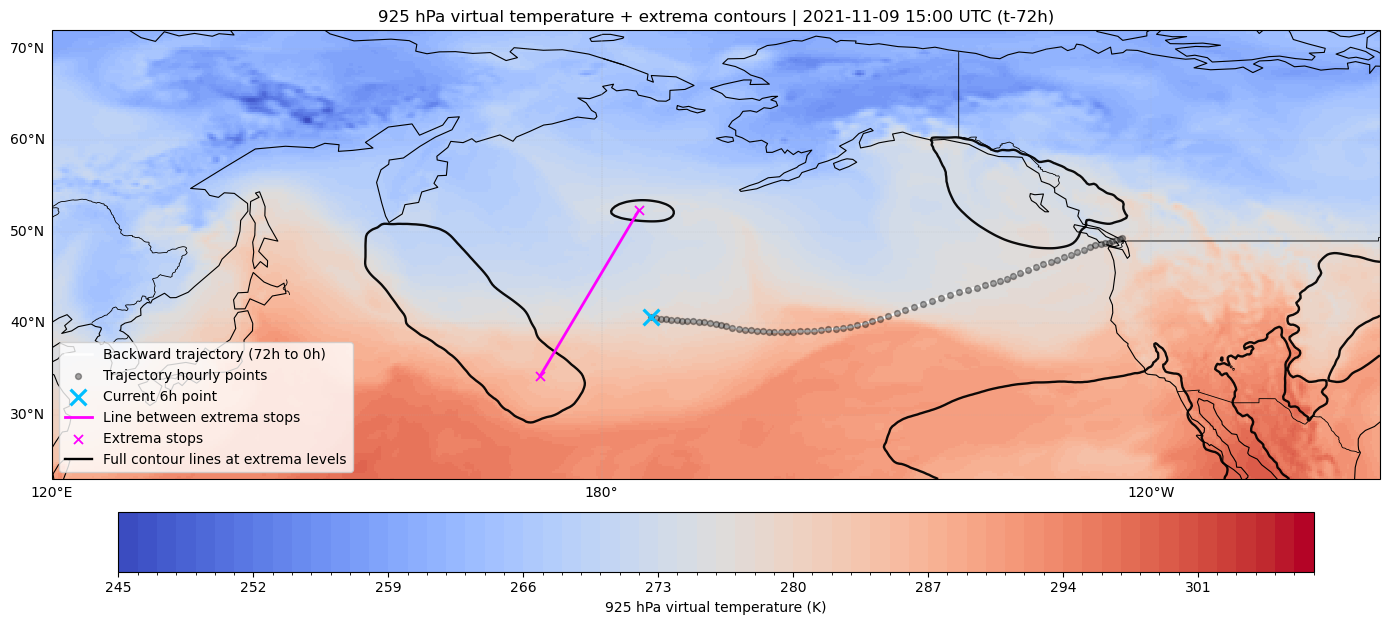

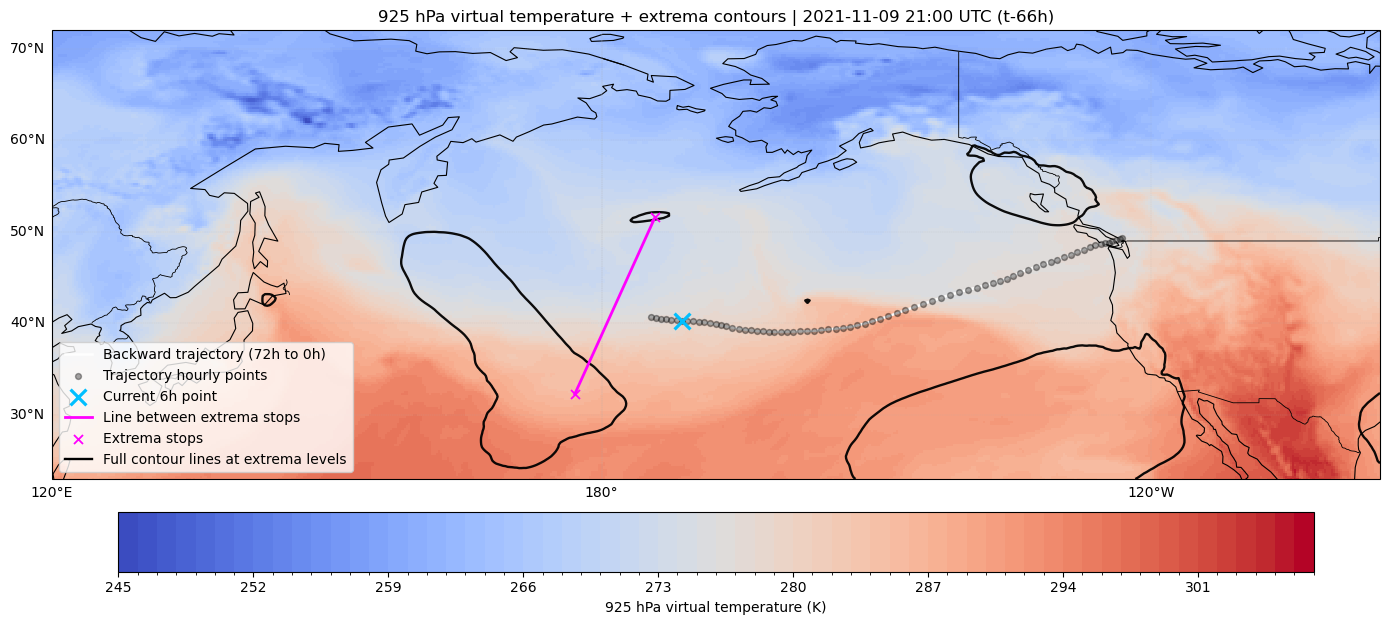

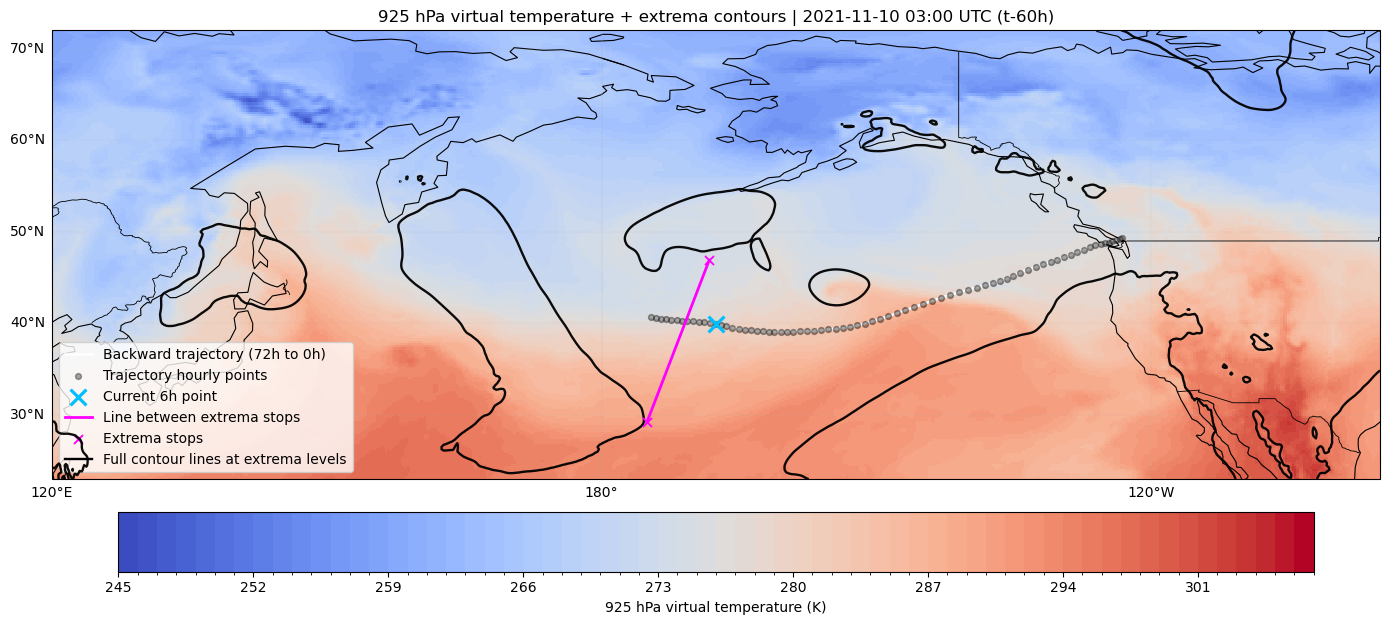

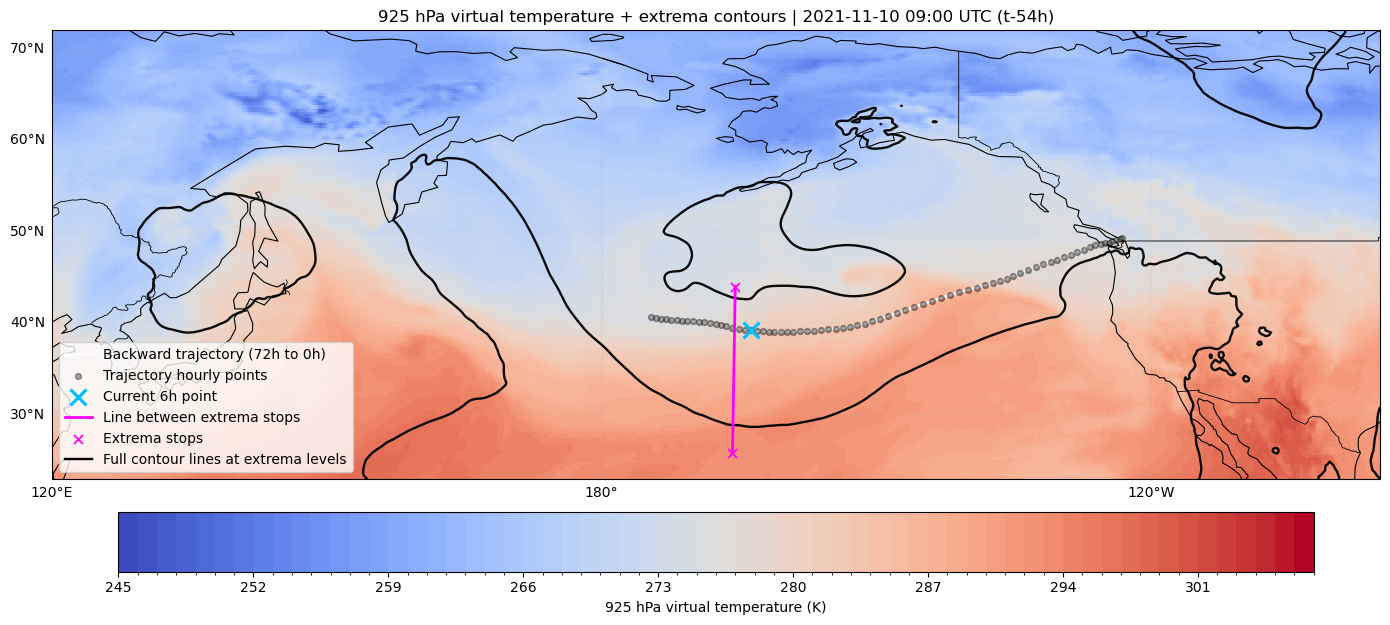

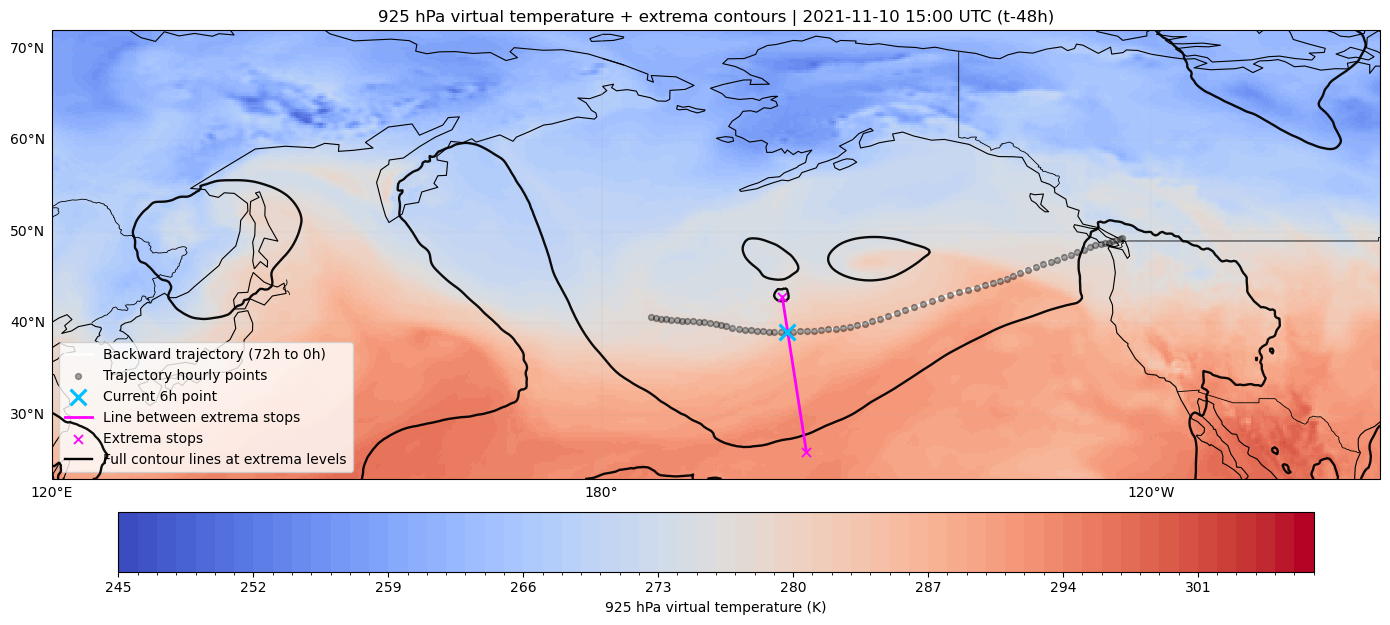

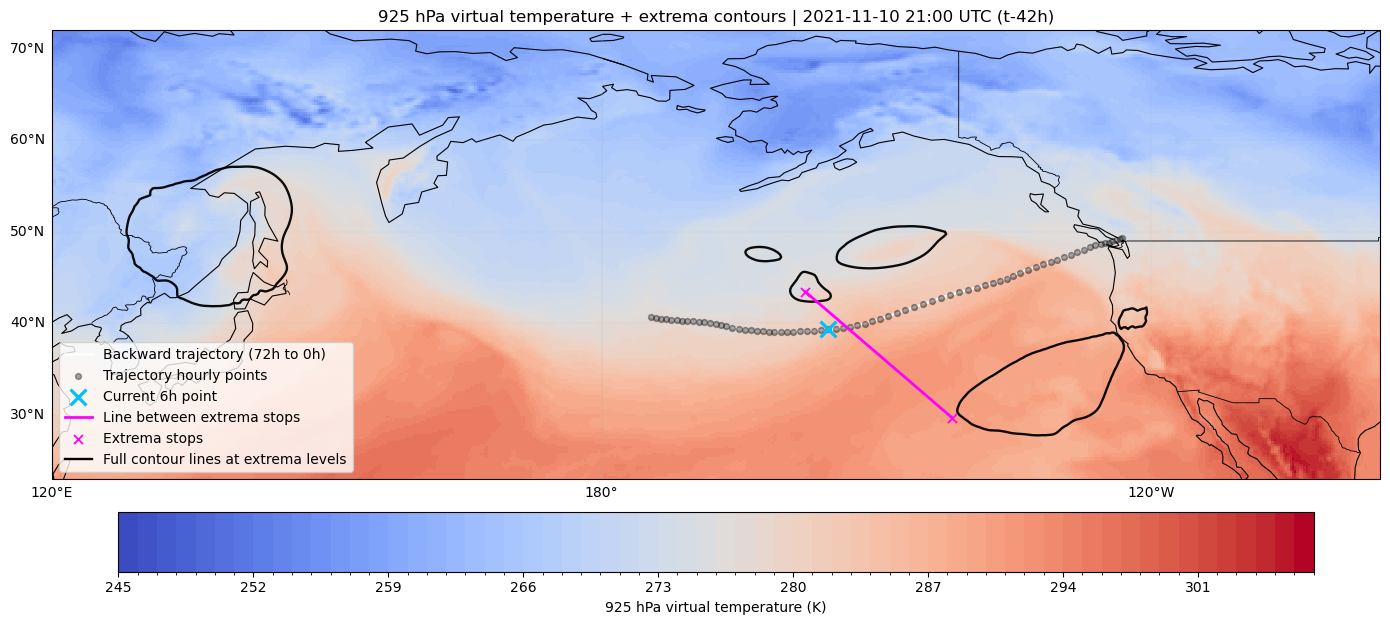

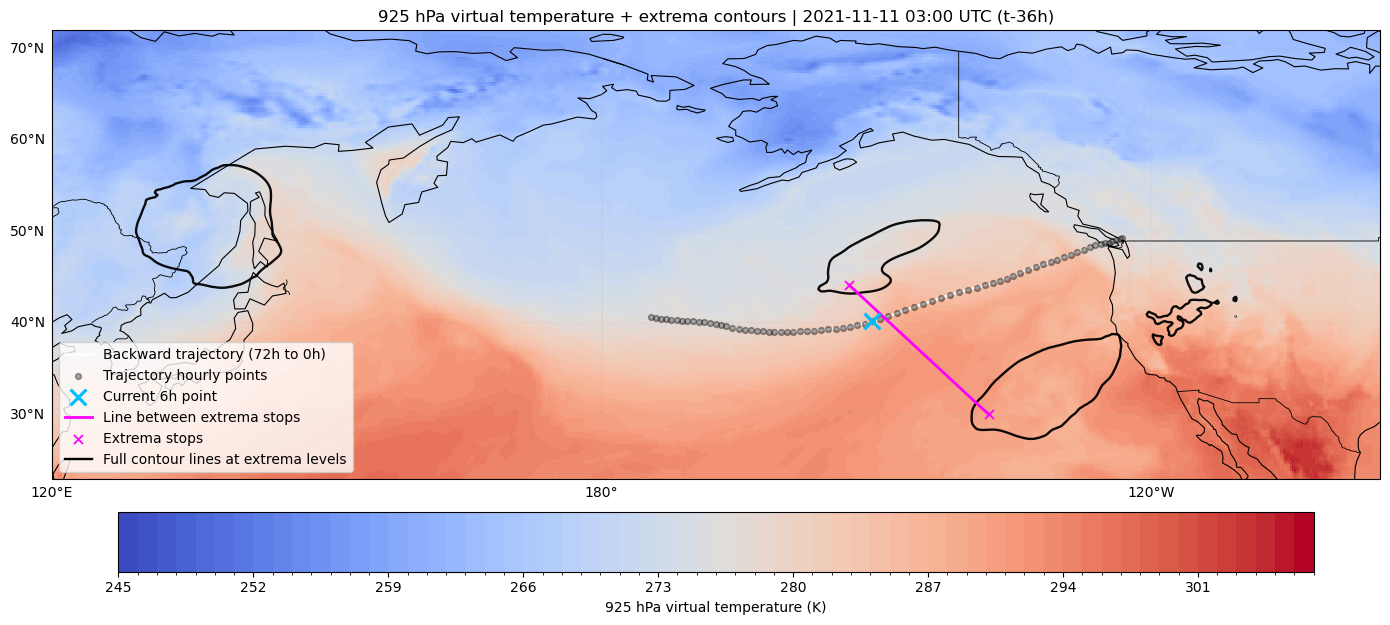

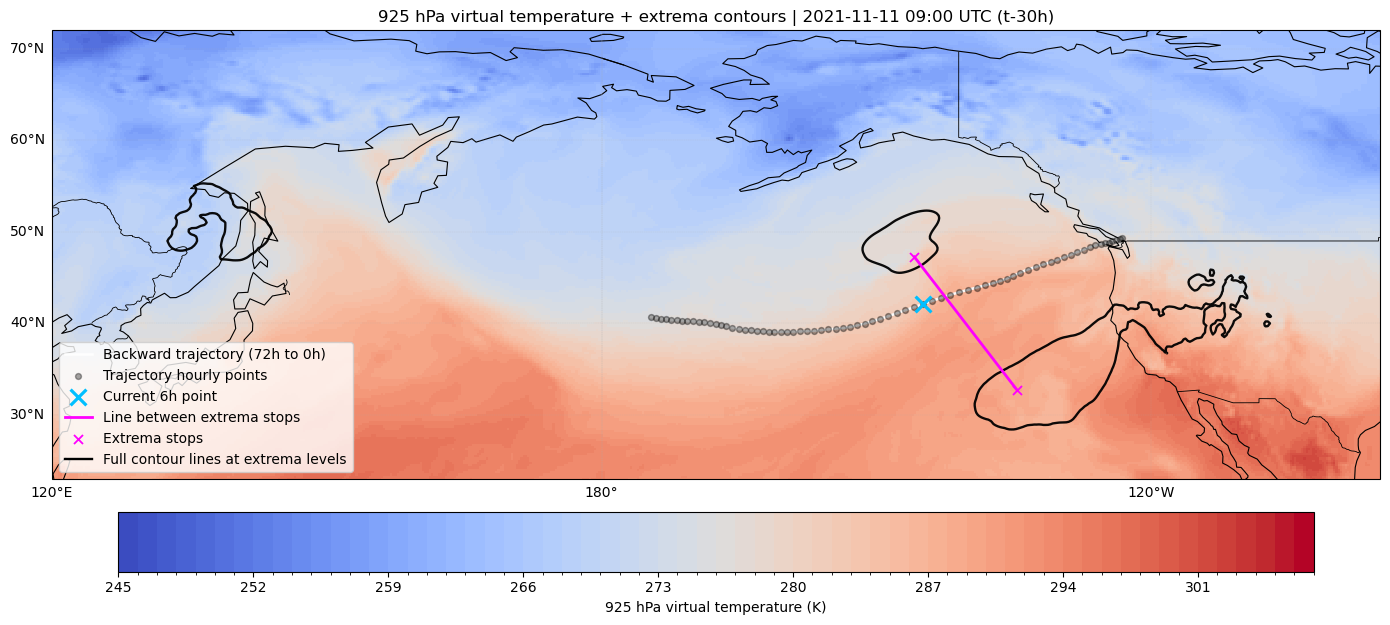

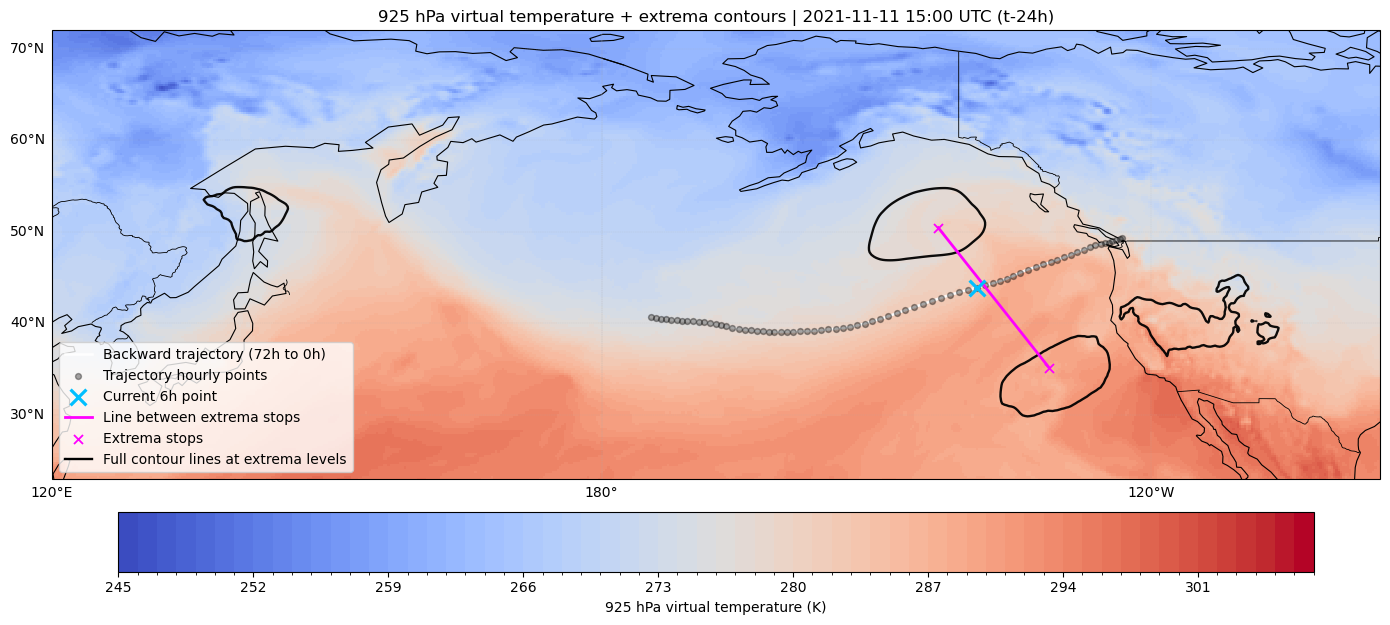

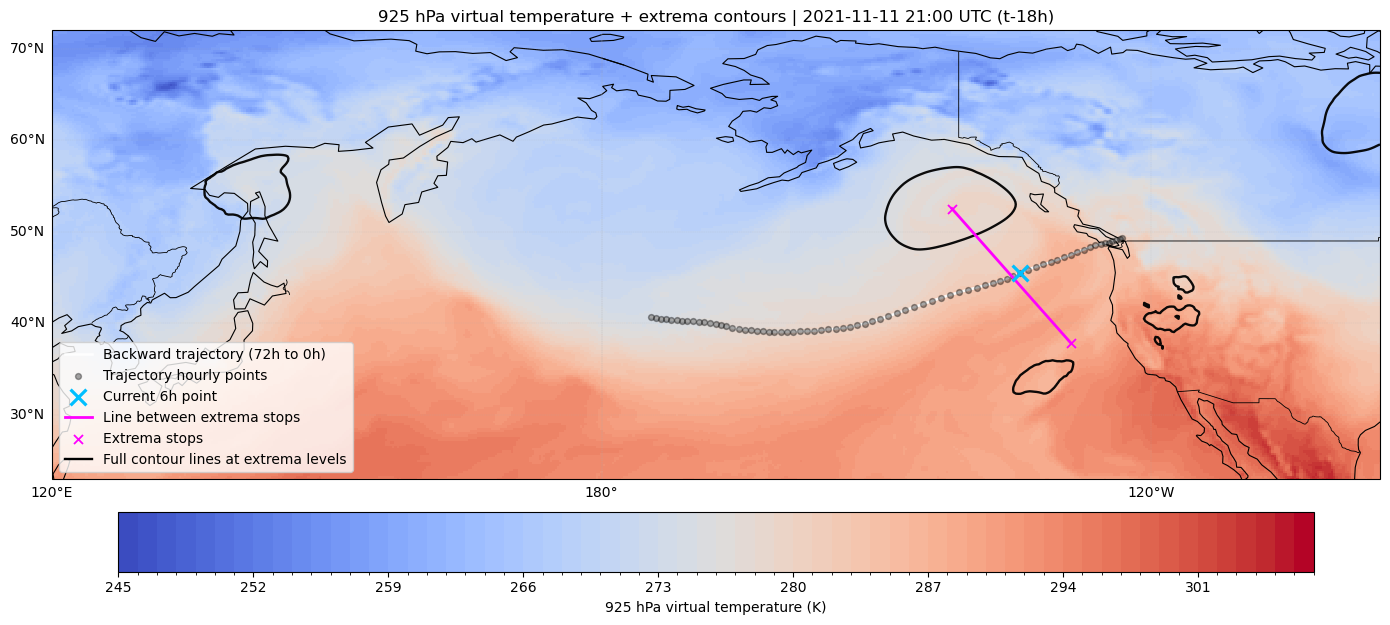

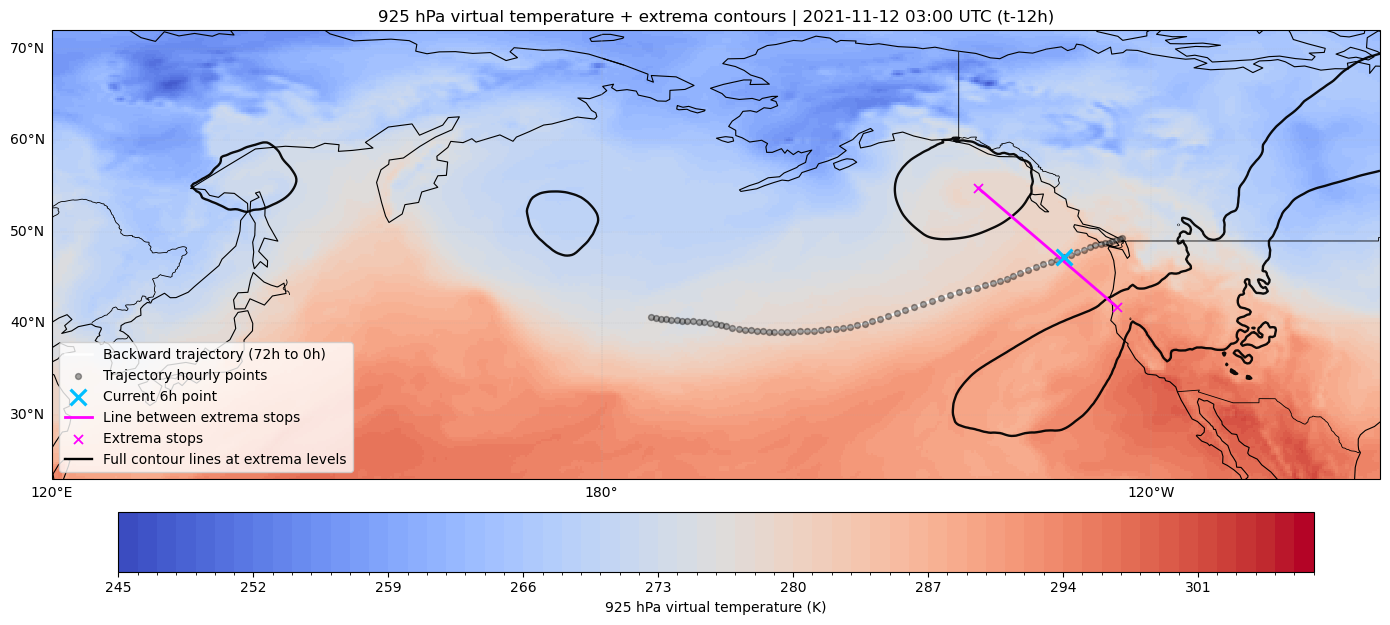

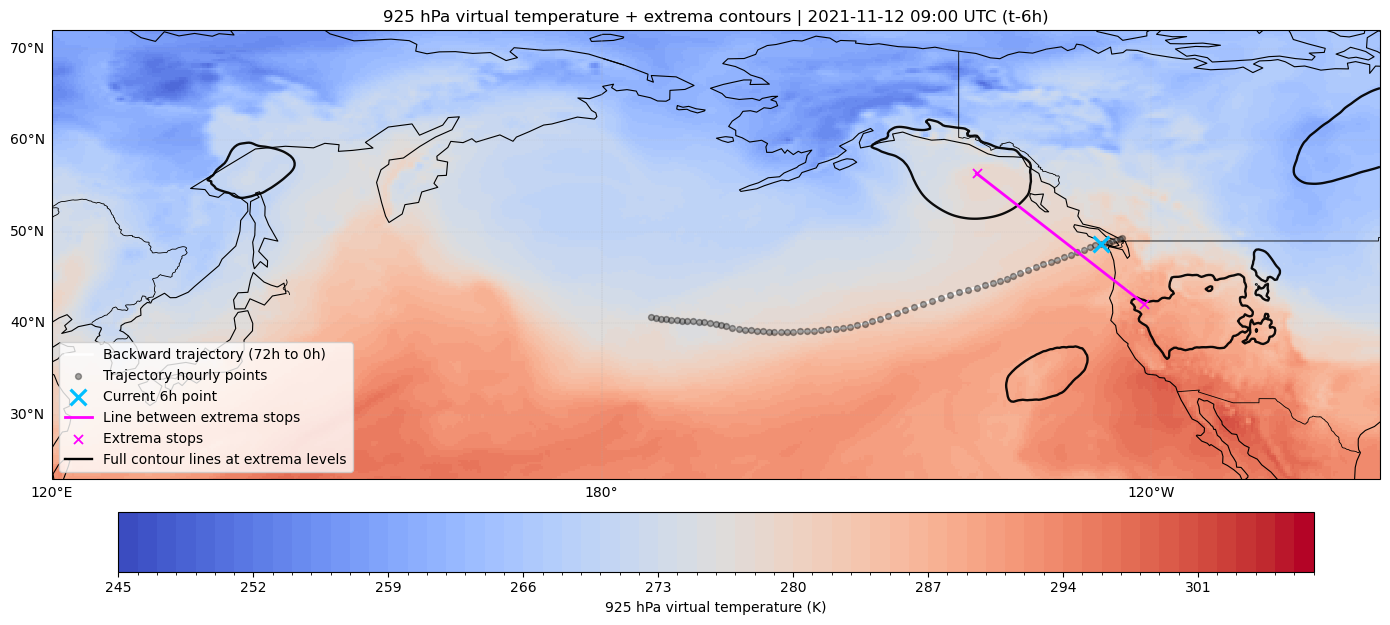

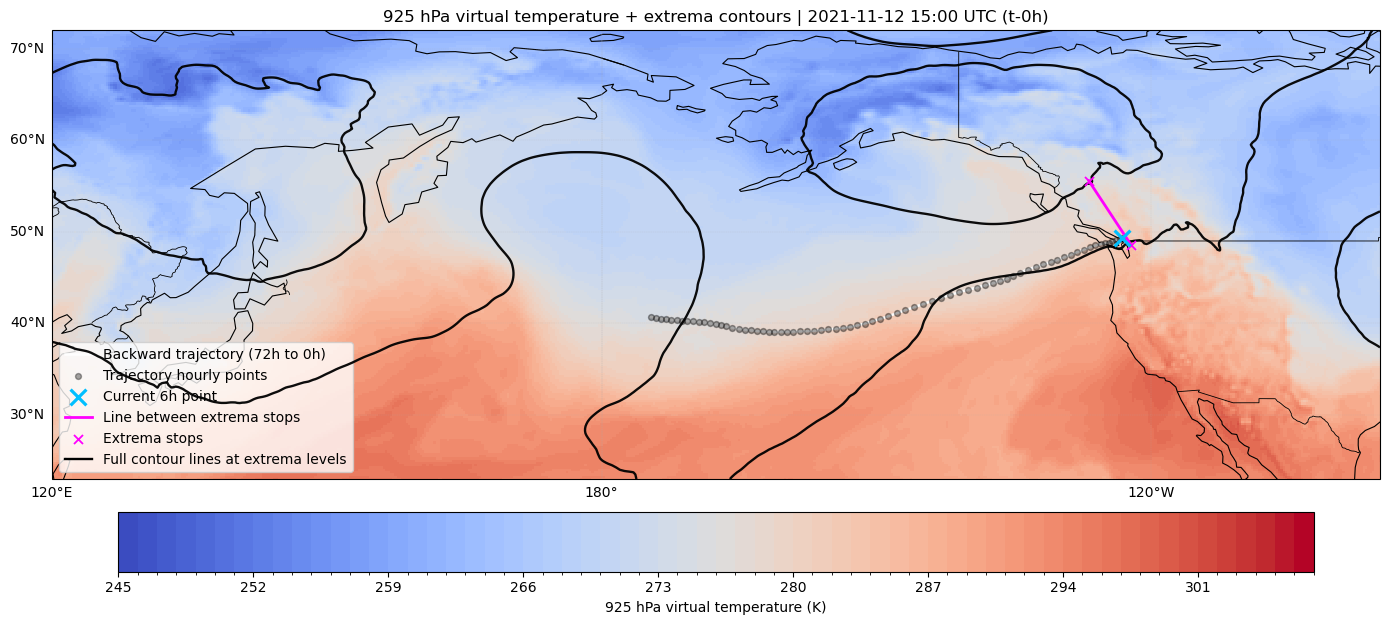

In [8]:
# Same style as old cell, but background = 925 hPa virtual temperature.
plot_background_with_extrema(
    extrema_context=extrema_context,
    background_frames=virtual_temp_frames,
    field_name="925 hPa virtual temperature",
    colorbar_label="925 hPa virtual temperature (K)",
    cmap_name="coolwarm",
    bin_width=1.0,
)


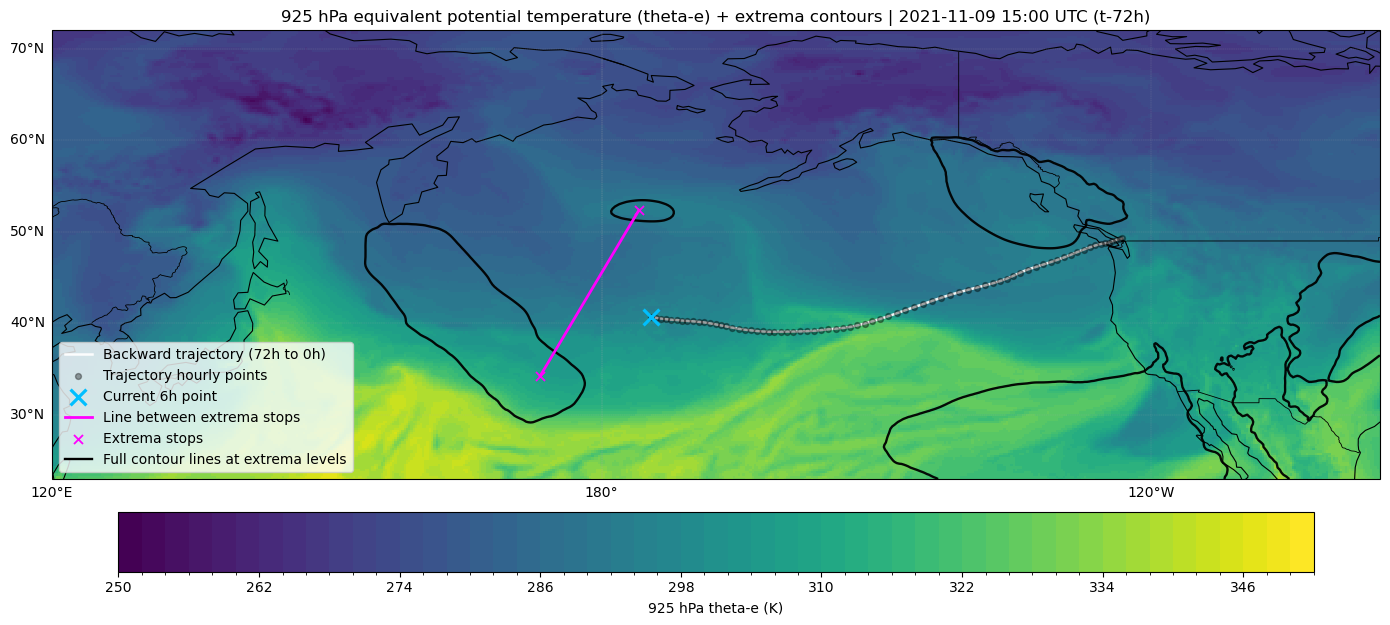

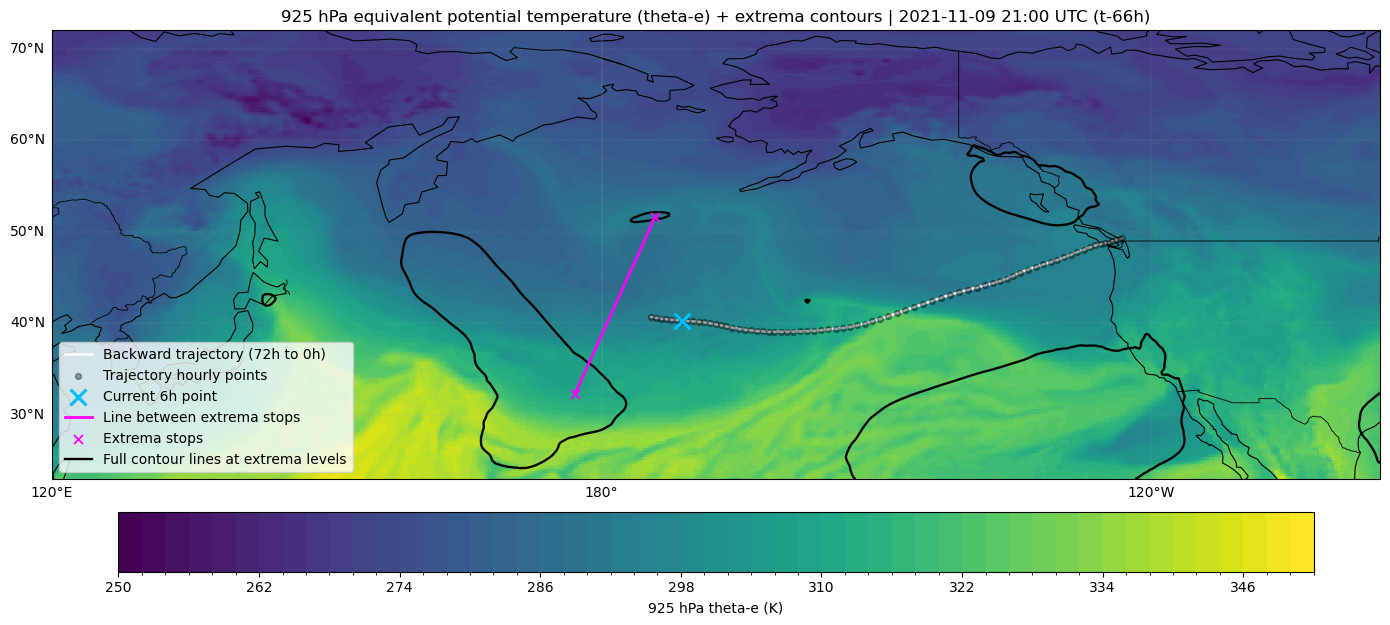

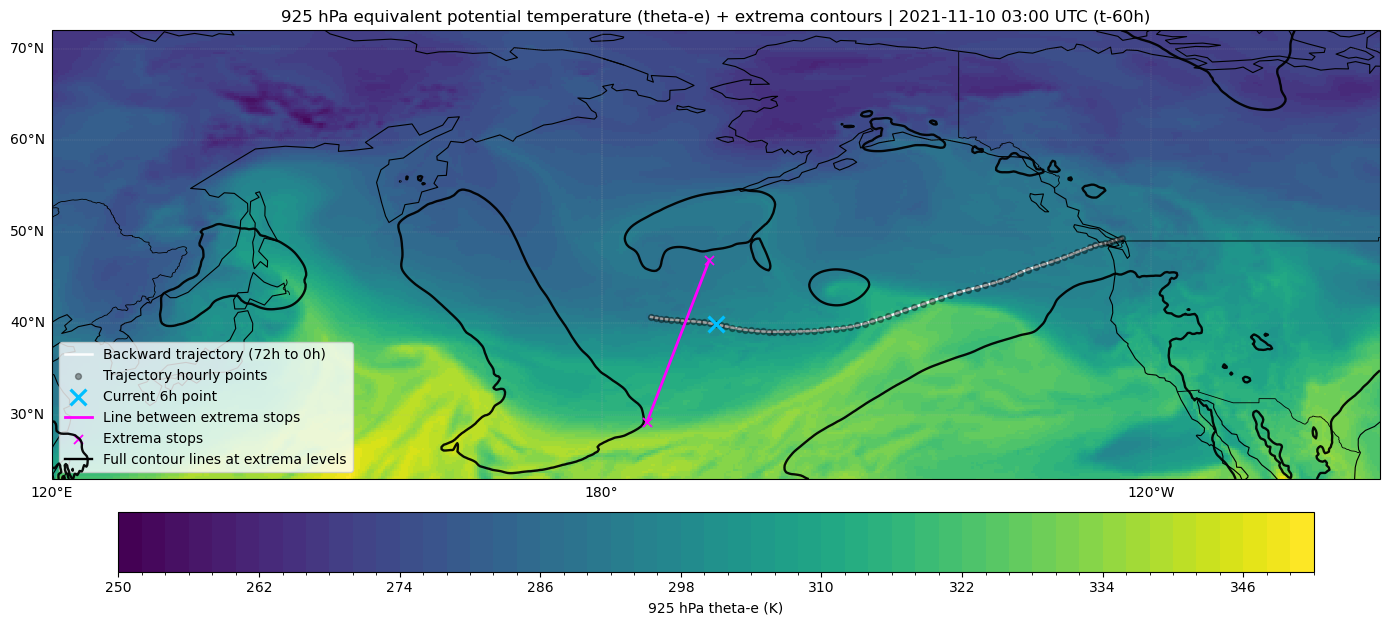

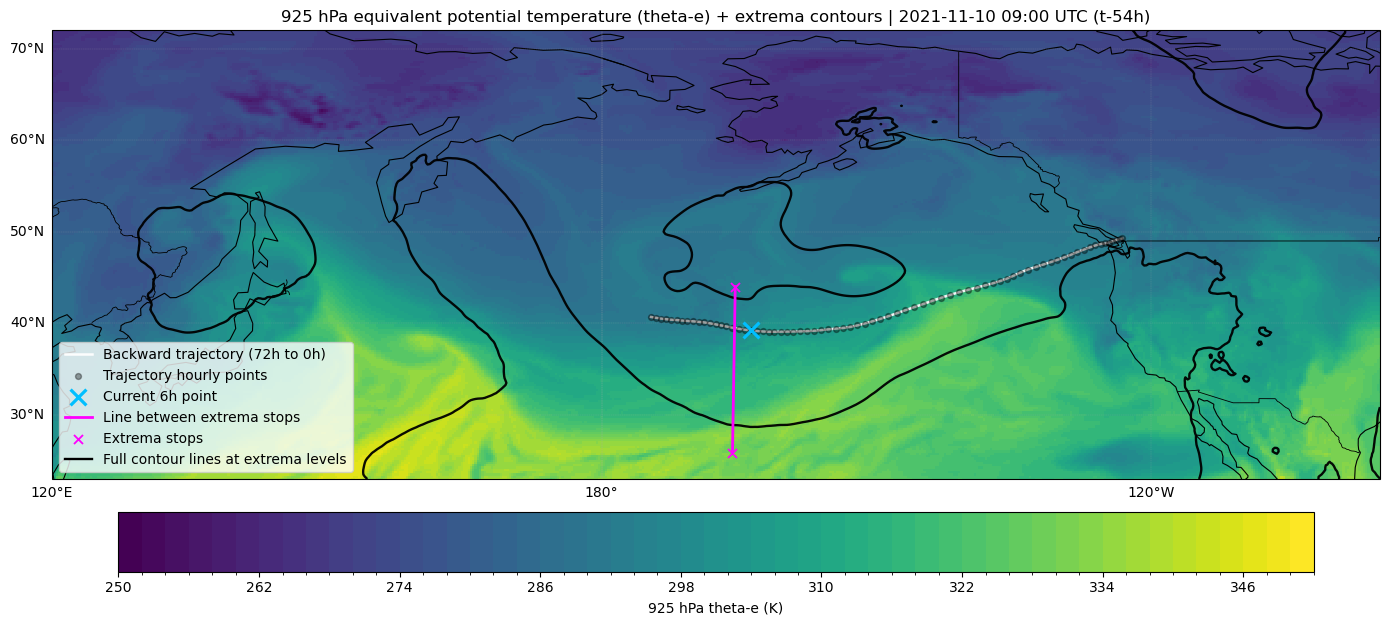

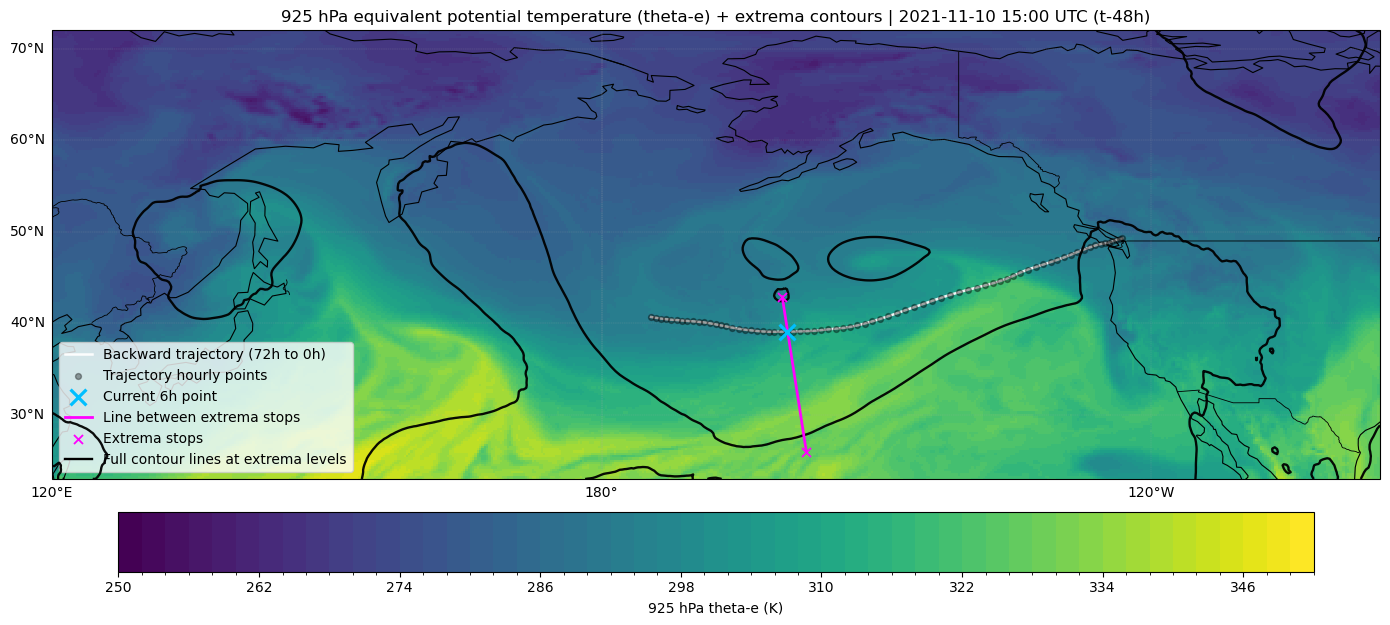

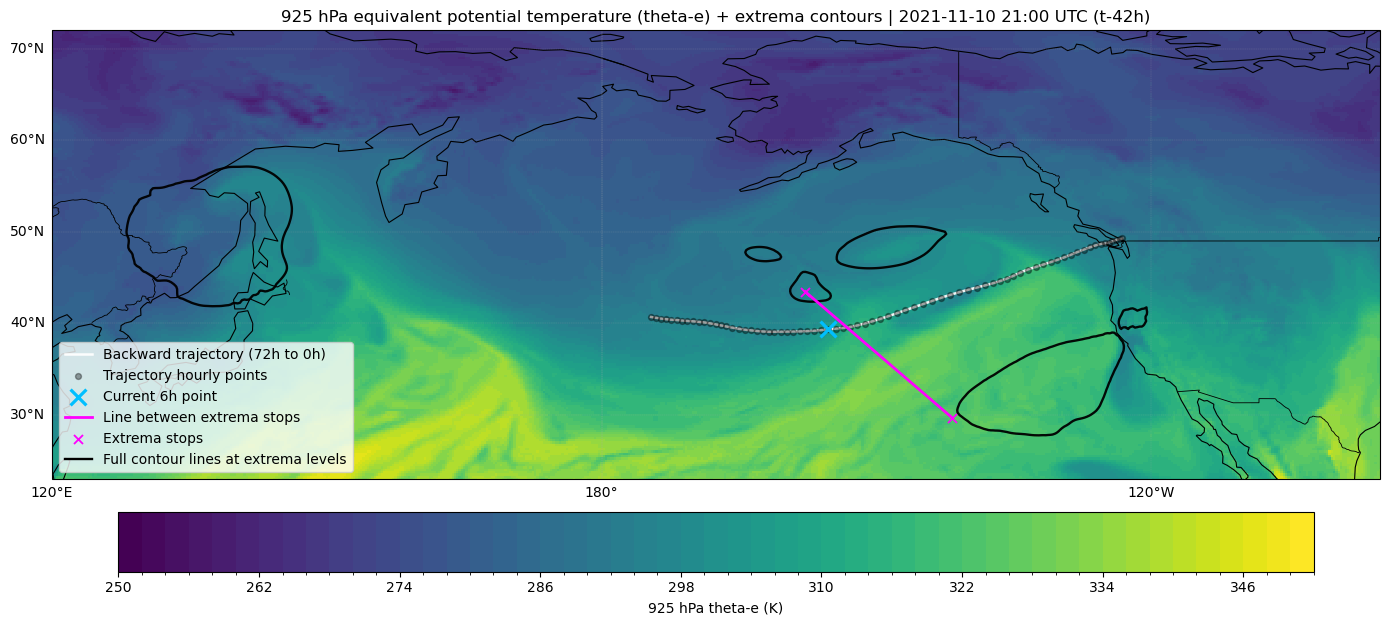

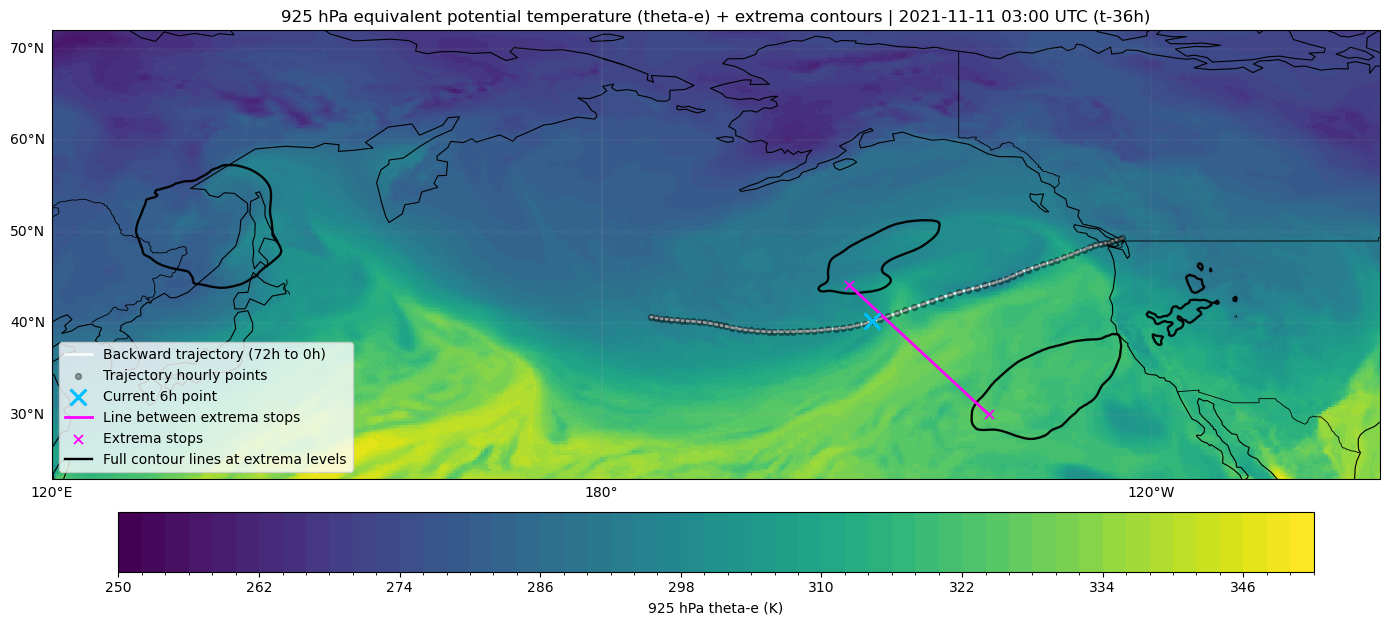

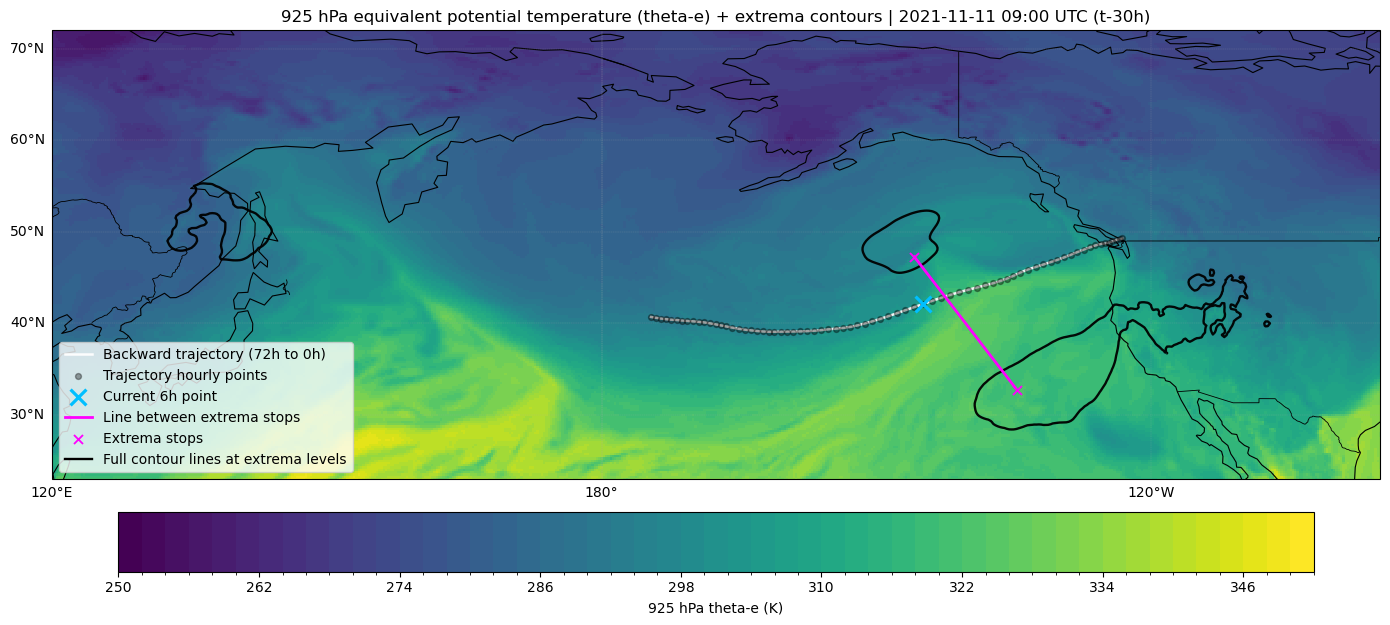

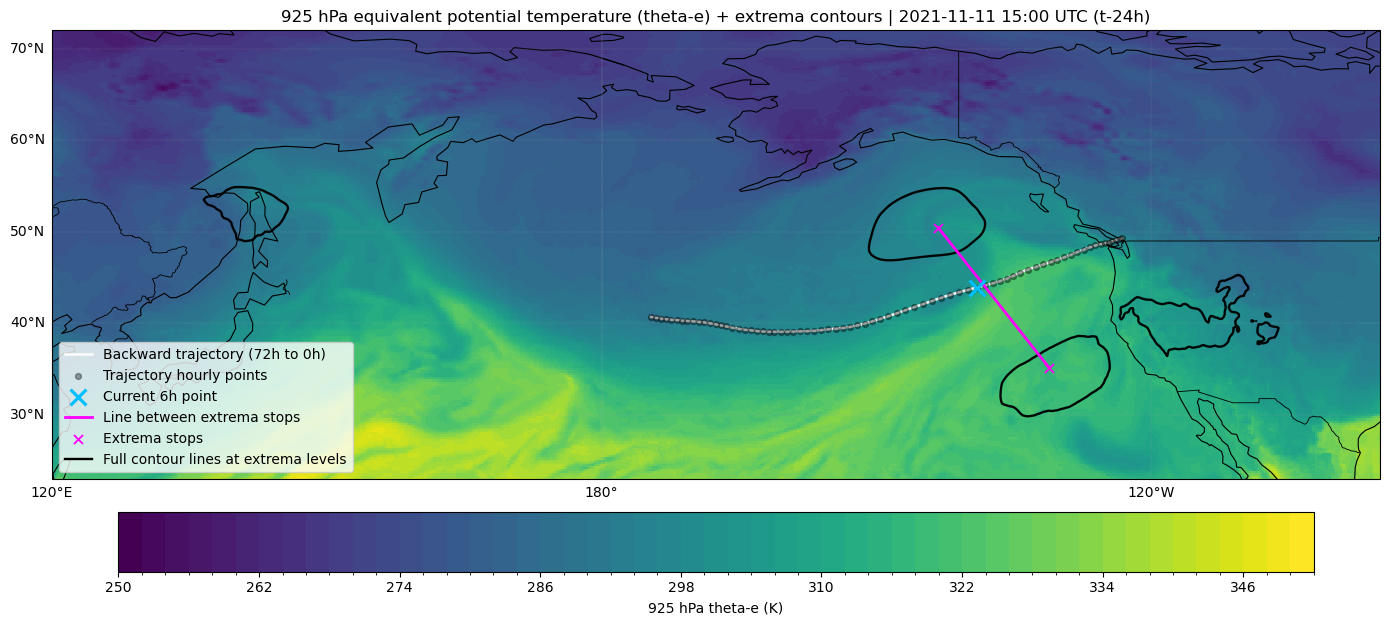

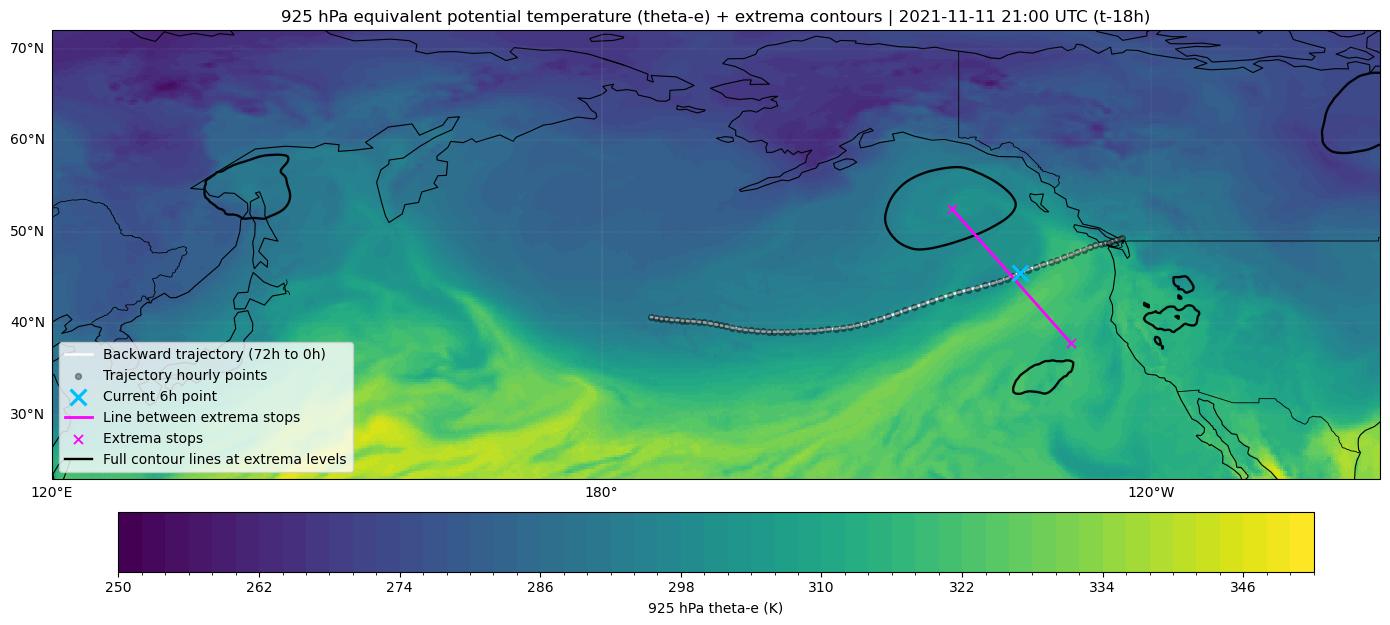

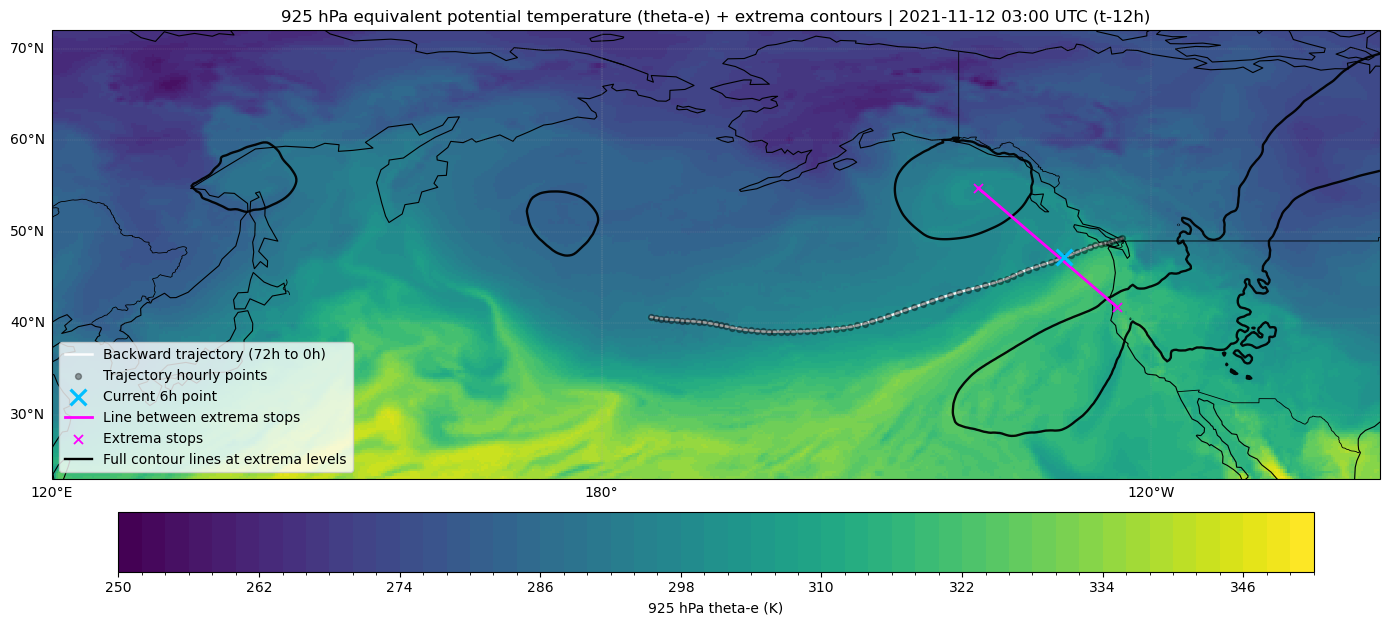

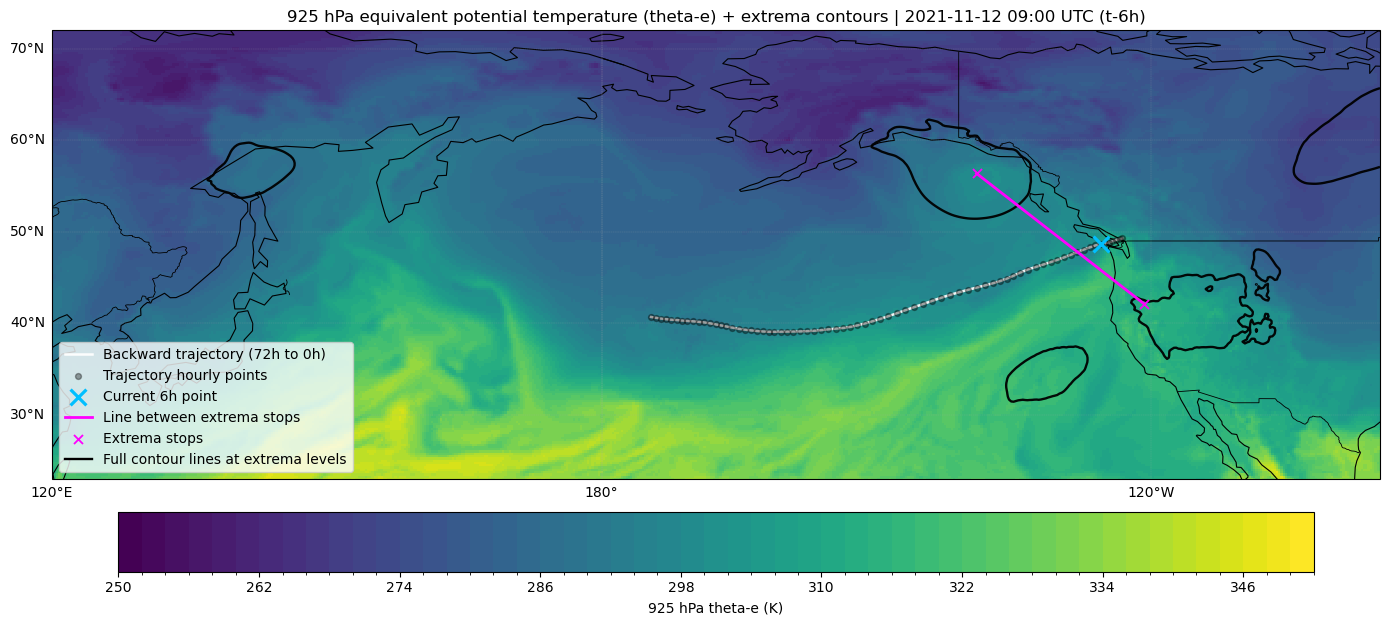

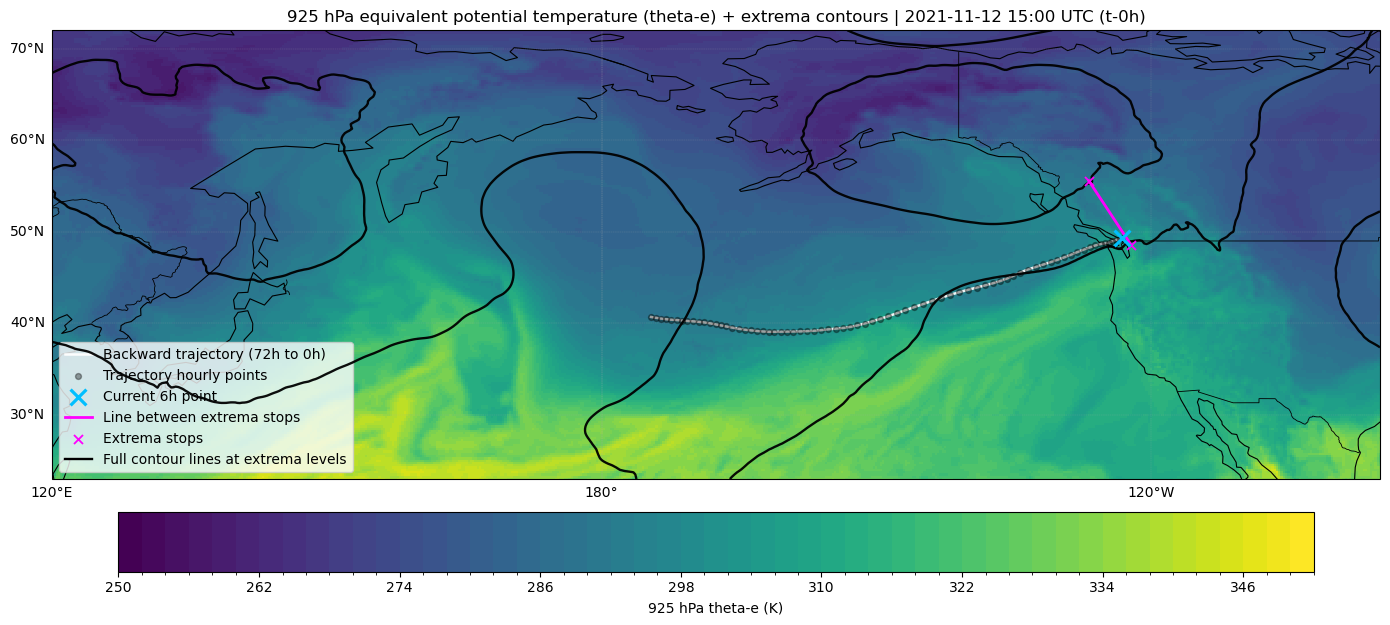

In [9]:
# Same style as old cell, but background = 925 hPa equivalent potential temperature.
plot_background_with_extrema(
    extrema_context=extrema_context,
    background_frames=theta_e_frames,
    field_name="925 hPa equivalent potential temperature (theta-e)",
    colorbar_label="925 hPa theta-e (K)",
    cmap_name="viridis",
    bin_width=2.0,
)
